# Segmentacja danych multispektralnych

![satelita](https://hackmd.io/_uploads/r1lA5vkx-l.jpg)

*Obraz wygenerowany przez narzędzie generowania obrazów DeepAI.*

## Wstęp

Ziemia nieustannie się zmienia &mdash; miasta się rozrastają, granice lasów przesuwają, a lodowce topnieją. Aby zrozumieć te procesy, naukowcy i inżynierowie coraz częściej sięgają po dane satelitarne. Dzięki nim możemy obserwować naszą planetę z kosmosu, monitorować stan środowiska i wykrywać zmiany, których często nie widać „gołym okiem”.

Jednym z kluczowych rodzajów takich danych są obrazy multispektralne, czyli zdjęcia wykonywane w wielu różnych zakresach promieniowania elektromagnetycznego. Każde z pasm dostarcza innych informacji o powierzchni Ziemi, a ściślej o tym, w jaki sposób dany materiał pochłania i odbija światło. Przykładowo: w świetle widzialnym dostrzegamy naturalne barwy roślin i gleby, natomiast podczerwień pozwala ocenić kondycję roślinności czy wilgotność gruntu.

Technologia ta umożliwia nieinwazyjne tworzenie map, analizę terenów uprawnych (np. pod kątem żyzności), śledzenie postępu suszy, a także monitorowanie zanieczyszczeń czy skutków katastrof naturalnych. Obrazy multispektralne stanowią dziś jeden z fundamentów nowoczesnej teledetekcji (ang. remote sensing).

Każdy materiał na Ziemi &mdash; woda, piasek, beton czy trawa - odbija promieniowanie w charakterystyczny dla siebie sposób. Ten unikalny wzór nazywamy sygnaturą spektralną. Analizując te sygnatury w różnych pasmach, możemy precyzyjnie zidentyfikować obiekty widoczne na zdjęciu.

W praktyce dane te bywają jednak zakłócone przez czynniki atmosferyczne (chmury, parę wodną, pyły) oraz drobne błędy pomiarowe czujników. Dlatego, zanim obrazy multispektralne posłużą do analizy, muszą zostać poddane odpowiedniemu przetworzeniu i korekcji.

## Zadanie

Twoim zadaniem jest przygotowanie klasy przetwarzającej zbiór danych oraz nauczenie modelu segmentującego obrazy multispektralne (mapy terenu).

Pierwszy etap zadania polega na stworzeniu funkcji, która przetworzy dane wejściowe w sposób maksymalizujący skuteczność modelu (bez użycia etykiet). Aby zwiększyć różnorodność zbioru treningowego i poprawić zdolność generalizacji, możesz zastosować różne techniki augmentacji danych, takie jak obrót, skalowanie czy dodawanie szumu (albo inne metody, które uznasz za stosowne).

Podczas analizy danych postaraj się dobrać **minimalny** zestaw pasm (kanałów), który pozwoli uzyskać wysoką jakość segmentacji. Zastanów się, które kanały niosą najwięcej informacji - przykładowo: czy podczerwień wpływa na detekcję roślinności? Wykorzystanie wszystkich pasm nie zawsze jest konieczne; często lepsze rezultaty daje selekcja tylko tych, które zawierają kluczowe informacje dla rozróżnianych klas. Pamiętaj, że nie musisz ograniczać się do surowych wartości kanałów - w procesie przetwarzania możesz wygenerować zupełnie nowe reprezentacje cech.

Drugim etapem jest stworzenie rozwiązania do segmentacji obrazów multispektralnych, czyli przypisanie każdemu pikselowi jednej z czterech klas: wody, lądu, roślinności lub terenów przemysłowych (zgodnie z poniższym przykładem). W tym celu możesz wykorzystać biblioteki takie jak PyTorch i scikit-learn.

![mapy_segmentacji](https://live.staticflickr.com/65535/54927654414_b325b31a02_c.jpg)

Do dyspozycji masz opatrzony etykietami zbiór treningowy i walidacyjny, na których możesz testować swoje podejście. Ostateczna ocena modelu zostanie przeprowadzona na ukrytym zbiorze testowym. Każdy obraz wejściowy składa się z 12 pasm spektralnych, jednak decyzja o tym, ile i które z nich wykorzystasz, należy do Ciebie.

## Opis danych

Dane podzielono na osobne zbiory:

- **treningowy** - $48$ próbek (obrazów),

- **walidacyjny** - $16$ próbek (obrazów).

Do ostatecznej oceny posłuży zbiór **testowy** składający się z $96$ próbek (obrazów), do którego nie masz dostępu.
Każda próbka to obraz o wymiarach $30 \times 30$ pikseli. Każdy piksel posiada przypisaną etykietę klasy (maskę segmentacji).
Każdy piksel opisany jest przez $12$ kanałów odpowiadających pomiarom odbicia światła w różnych zakresach długości fali.

## Kryterium oceny

Twój wynik zależy od dwóch czynników: jakości segmentacji na ukrytym zbiorze testowym oraz liczby kanałów, które zdecydujesz się wykorzystać na wejściu modelu.

Pierwszy składnik funkcji oceny związany jest z liczbą wykorzystanych kanałów $N\_channels$. Oryginalnie każdy piksel złożony jest z 12 kanałów i za użycie wszystkich kanałów otrzymasz 0 punktów za tę część zadania. Wszystkie rozwiązania stosujące co najwyżej 3 kanały otrzymają komplet punktów za ten składnik funkcji oceny, z kolei rozwiązania używające $\lbrace 4, 5, 6, ..., 11\rbrace$ kanałów zostaną ocenione według kwadratowej funkcji skali:

$$\mathtt{channel\_evaluation} = 
\begin{cases} 
    0 &\quad \text{jeżeli }  N\_channels \geq 12 \\
    100 &\quad \text{jeżeli }  N\_channels \leq 3 \\
    100 \cdot \left( \dfrac{12 - N\_channels}{12 - 3} \right)^2 &\quad \text{w pozostałych przypadkach}.
\end{cases}$$

Przykładowo, za zastosowanie 10 kanałów otrzymasz jedynie 5 punktów za tę część zadania, pomnożone przez współczynnik wynoszący $0.25$.
Drugi składnik funkcji oceny związany jest z jakością segmentacji dla map zastosowanych w zadaniu. Wykorzystamy do tego miarę $\text{IoU}$ (Intersection over Union), która ocenia stosunek ilości prawidłowo sklasyfikowanych pikseli danej klasy w danym obrazie, w odniesieniu do ilości wszystkich pikseli tej klasy występujących w rzeczywistej mapie (*ground truth*) lub predykcji modelu. Finalnie, policzona zostanie średnia po wszystkich klasach oraz obrazach znajdujących się w zbiorze testowym. Dla każdego obrazka liczona będzie średnia tylko po klasach, które pojawiają się w *ground truth*.

$$\text{IoU} = \dfrac{1}{M \cdot N} \cdot \sum\limits_{i=1}^{N} \sum\limits_{j=1}^{M_i} \dfrac{\text{ilość prawidłowo sklasyfikowanych pikseli j-tej klasy w i-tej mapie}}{\text{ilość pikseli j-tej klasy w łącznym rzeczywistym obszarze oraz predykcji modelu dla i-tej mapy }}$$

gdzie $N$ to ilość obrazów w danym zbiorze (np. testowym), zaś $M_i$ jest liczbą klas rzeczywiście występującą w $i$-tej mapie. Jeśli średnie $\text{IoU}$ wyniesie nie więcej niż 0.6, otrzymasz za tę część zadania 0 punktów, a jeżeli co najmniej 0.8, wówczas otrzymasz za tę część zadania pełną pulę punktów.

$$\mathtt{segmentation\_evaluation} = 
\begin{cases} 
    0 &\quad \text{jeżeli }  \text{IoU} \leq 0.6 \\
    100 &\quad \text{jeżeli }  \text{IoU} \geq 0.8 \\
    100 \cdot \dfrac{\text{IoU} - 0.6}{0.8 - 0.6} &\quad \text{w pozostałych przypadkach}
\end{cases}$$

Przykład obliczania $\text{IoU}$ dla jednej z klas (wyrażonej za pomocą niebieskich kwadratów) znajduje się na poniższym obrazku. Wynik końcowy $\text{IoU}$ jest uśredniany po wszystkich klasach obecnych w danym obrazie, a także po wszystkich obrazach w zbiorze.

![IoU](https://live.staticflickr.com/65535/54922482577_1a5222581f_b.jpg)

Ostateczny wynik za zadanie będzie stanowił $25\%$ oceny za ilość użytych kanałów oraz $75\%$ punktów za jakość segmentacji, zgodnie ze wzorem:

$$\text{score} = 0.25 \cdot \mathtt{channel\_evaluation} + 0.75 \cdot \mathtt{segmentation\_evaluation}$$

**UWAGA!** Jeśli $\text{IoU}$ wyniesie mniej niż 0.5, otrzymasz 0 punktów za całe zadanie, niezależnie od użytej ilości kanałów!


## Ograniczenia

- Twoje rozwiązanie będzie testowane na Platformie Konkursowej bez dostępu do Internetu oraz w środowisku z GPU. 
- Trening modelu i ewaluacja Twojego finalnego rozwiązania na Platformie Konkursowej nie mogą trwać dłużej niż 5 minut z użyciem GPU.
- Klasa dokonująca wstępnego przekształcenia danych `YourPreprocessing` nie może w żaden sposób korzystać z etykiet zbiorów danych (może tylko przetwarzać same próbki), a segmentacja ma być wykonywana bezpośrednio w klasie `YourModel`.

## Pliki Zgłoszeniowe

Ten notebook uzupełniony o Twoje rozwiązanie (patrz klasa `YourModel` oraz klasa `YourPreprocessing`), w którym przygotujesz zestaw zawierający przekształcanie danych z potencjalną redukcją i modyfikacją kanałów oraz model dokonujący segmentacji na przetworzonych danych.

## Ewaluacja

Pamiętaj, że podczas sprawdzania flaga `FINAL_EVALUATION_MODE` zostanie ustawiona na True.

Za to zadanie możesz zdobyć pomiędzy 0 a 100 punktów. Liczba punktów, którą zdobędziesz, będzie wyliczona na (tajnym) zbiorze testowym na Platformie Konkursowej na podstawie wyżej wspomnianego wzoru, zaokrąglona do liczby całkowitej. Jeśli Twoje rozwiązanie nie będzie spełniało powyższych kryteriów, nie będzie wykonywać się prawidłowo lub zostanie wykryta próba oszustwa, otrzymasz za zadanie 0 punktów.

## Kod Startowy

W tej sekcji inicjalizujemy środowisko poprzez zaimportowanie potrzebnych bibliotek i funkcji. Przygotowany kod ułatwi Tobie efektywne operowanie na danych i budowanie właściwego rozwiązania.

In [1]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################

FINAL_EVALUATION_MODE = False  # Podczas sprawdzania ustawimy tą flagę na True.

In [2]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################

import os
import random
from tqdm import tqdm

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, TensorDataset, DataLoader

# Dodatkowe biblioteki, któe możesz wykorzystać w Twoim rozwiązaniu
import xgboost
import sklearn

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = "./data"
TRAIN_DATA_PATH = os.path.join(DATA_DIR, "train.npz")
VALID_DATA_PATH = os.path.join(DATA_DIR, "valid.npz")

assert torch.cuda.is_available(), "Nie znaleziono karty graficznej (GPU)!"

In [3]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################

seed = 12345

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ["PYTHONHASHSEED"] = str(seed)

### Ładowanie Danych
Za pomocą poniższego kodu wczytujemy dane zawierające obrazy multispektralne oraz odpowiadające im maski segmentacji. Dane te będą podstawą do trenowania i walidacji Twojego modelu segmentującego.

In [4]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################
# Komórka zawierająca funkcje pomocnicze do przygotowania danych.

class BaseDataset(Dataset):
    """
    Klasa zbioru danych multispektralnych.
    """
    def __init__(self, data_path: str):
        data = np.load(data_path)
        self.bands = data["bands"]
        self.segmentations = data["segmentations"]

    def __len__(self):
        """Zwraca liczbę próbek w zbiorze danych."""
        return self.bands.shape[0]

    def __getitem__(self, idx):
        """Zwraca próbkę o indeksie idx - jej pasma multispektralne oraz segmentację."""
        bands = self.bands[idx]
        segmentations = self.segmentations[idx]

        bands = torch.from_numpy(bands).float()
        segmentations = torch.from_numpy(segmentations).long()

        return bands, segmentations

def setup_data():
    """
    Pobiera zbiory danych wykorzystane w zadaniu.
    """
    import gdown
    os.makedirs(DATA_DIR, exist_ok=True)

    if not os.path.exists(TRAIN_DATA_PATH):
        url = "https://drive.google.com/uc?id=1Nfv3Kd9W8ypjr8RL1jY3VF3yTKU934lz"
        gdown.download(url, TRAIN_DATA_PATH, fuzzy=True)
    
    if not os.path.exists(VALID_DATA_PATH):
        url = "https://drive.google.com/uc?id=1WUwayYErm4CXI7zHUAmZmi23doIKmDm3"
        gdown.download(url, VALID_DATA_PATH, fuzzy=True)

if not FINAL_EVALUATION_MODE:
    setup_data()

### Kod z Kryterium Oceniającym

Kod, zbliżony do poniższego, będzie używany do oceny rozwiązania na zbiorze testowym.

In [5]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################

def calculate_miou(y_true, y_pred):
    """
    Kalkuluje metrykę mIoU (mean Intersection over Union) używaną do oceny modelu.
    Funkcja pomocnicza wykorzystywana przy ocenie rozwiązania.
    """
    assert y_true.shape == y_pred.shape
    assert y_true.device == y_pred.device

    num_classes = 4
    device = y_true.device
    batch_size = y_true.shape[0]
    y_true_flat = y_true.reshape(batch_size, y_true.shape[1] * y_true.shape[2])
    y_pred_flat = y_pred.reshape(batch_size, y_pred.shape[1] * y_pred.shape[2])

    # Końcowa średnia jest liczona tylko dla klas obecnych w danych referencyjnych (ground truth)
    intersections = torch.zeros((batch_size, num_classes), dtype=torch.float32, device=device)
    unions = torch.zeros((batch_size, num_classes), dtype=torch.float32, device=device)
    true_present = torch.zeros((batch_size, num_classes), dtype=torch.bool, device=device)

    for cls in range(num_classes):
        y_true_c = (y_true_flat == cls)
        y_pred_c = (y_pred_flat == cls)
        true_present[:, cls] = torch.any(y_true_c, dim=1)

        intersections[:, cls] = torch.sum(y_true_c & y_pred_c, dim=1).to(torch.float32)
        unions[:, cls] = torch.sum(y_true_c | y_pred_c, dim=1).to(torch.float32)

    # Oblicza liczbę istotnych klas dla każdej próbki
    num_present_classes = torch.sum(true_present, dim=1).to(torch.float32)

    # Mimo że obliczenia są wykonywane dla wszystkich klas, sumujemy tylko te klasy, które faktycznie występują (w danych referencyjnych)
    iou_per_class = torch.nan_to_num(intersections / unions, nan=0.0)
    sum_iou = torch.sum(iou_per_class * true_present, dim=1)
    miou_scores = torch.nan_to_num(sum_iou / num_present_classes, nan=0.0).tolist()
    assert len(miou_scores) == batch_size

    return miou_scores


def calculate_channel_count(dataloader):
    """
    Funkcja pomocnicza wykorzystywana przy ocenie rozwiązania.
    Kalkuluje ilość pasm wykorzystywanych przy treningu i ewaluacji modelu.
    """
    tensors = dataloader.dataset.tensors
    
    if len(tensors) != 2:
        raise ValueError("W zbiorze danych powinny znajdować się tylko etykiety i obrazy (__getitem__ powinien zwracać krotkę o wymiarowości 2)")
    
    x, _ = tensors
    
    # x.shape [dataset size, channels, height, width]
    if x.ndim != 4:
        raise ValueError("Przetworzone dane muszą posiadać 4 wymiary [batch size, channels, height, width]")

    if x.shape[0] < 15: #zbiór walidacyjny jest najmniejszy i ma 15 próbek 
        raise ValueError(f"Pierwszy wymiar jest zarezerwowany dla rozmiaru datasetu, Twój kod nie powinien go zmieniać!")

    if x.shape[2] != 30 or x.shape[3] != 30:
        raise ValueError("Przetworzone dane muszą mieć wymiary 30x30 na 3 i 4 wymiarze (.shape[2] == .shape[3] == 30)")

    channels_count = x.shape[1]
    return channels_count

def transform_dataset(preprocessing, dataset:BaseDataset) -> TensorDataset:
    """
    Przetwarza wskazany zbiór danych i zachowuje go w pamięci komputera (RAM). 
    Wywołuje zaimplementowaną przez uczestnika funkcję .transform w klasie przygotowującej zbiory danych.
    """
    processed_labels = []
    processed_images = []
    
    for raw_image, label in dataset:
        processed_labels.append(label.clone())
        
        transformed_image = preprocessing.transform(raw_image.clone())
        processed_images.append(transformed_image)

    labels_tensor = torch.stack(processed_labels) 
    images_tensor = torch.stack(processed_images)  
    memory_dataset = TensorDataset(images_tensor, labels_tensor)
    return memory_dataset

def evaluate(train_model, preprocessing, data_path: str):
    """
    Główna funkcja oceniająca zadanie. 
    Taka sama funkcja będzie wywołana na Platformie Konkursowej.

    1. Dopasowuje klasę przetwarzania danych na zbiorze treningowym.
    2. Przetwarza wskazany zbiór danych za pomocą dopasowanej klasy.
    3. Ocenia model za pomocą metryki mIoU na wskazanym przetworzonym zbiorze danych.
    4. Ocenia ilość pasm wykorzystanych przy ocenie modelu - sprawdza kształt danych.
    """

    # Wczytuje zbiór treningowy i dopasowuje na nim klasę przygotowywania danych 
    train_ds = BaseDataset(data_path=TRAIN_DATA_PATH)
    preprocessing = preprocessing()
    assert hasattr(preprocessing, "fit"), "Funkcja przygotowująca dane musi implementować metodę .fit"
    preprocessing.fit(train_ds)
    
    # Wczytuje docelowy zbiór danych i przetwarza go za pomocą klasy słuącej do przygotowywania danych
    target_ds = BaseDataset(data_path=data_path)
    assert hasattr(preprocessing, "transform"), "Funkcja przygotowująca dane musi implementować metodę .transform"
    transformed_dataset = transform_dataset(preprocessing=preprocessing, dataset=target_ds)
    dataloader = DataLoader(transformed_dataset, batch_size=8, shuffle=False)

    model = train_model()

    if hasattr(model, "to") and callable(getattr(model, "to", None)):
        model = model.to(DEVICE)

    if hasattr(model, "eval") and callable(getattr(model, "eval", None)):
        model.eval()

    mious = []

    # Ocenia model za pomocą metryki mIoU
    with torch.no_grad():
        
        for x, y in dataloader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            y_pred = model(x)
            if hasattr(y_pred, "to") and callable(getattr(y_pred, "to", None)):
                y_pred = y_pred.to(DEVICE)
            if not torch.is_tensor(y_pred):
                y_pred = torch.tensor(y_pred)
            y_pred = torch.argmax(y_pred, dim=1)

            assert y_pred.shape == y.shape
            assert y_pred.max() <= 4 and y_pred.min() >= 0

            miou = calculate_miou(y, y_pred)
            mious.extend(miou)

    # Ocenia ilość pasm wykorzystanych przy ocenie modelu
    channels_count = calculate_channel_count(dataloader=dataloader)
    
    # Wylicza średnią mIoU po wszystkich próbkach
    miou = sum(mious) / len(mious)

    return miou, channels_count
    
def compute_score(miou, channels_count):
    """
    Oblicza wynik za zadanie, kalkuluje ilość ostatecznych punktów za zadanie za pomocą wzoru podanego w treści zadania.
    Taka sama funkcja będzie wywołana na Platformie Konkursowej.
    """
    band_score = max(0, min(100, 100 * ((12 - channels_count) / (12 - 3))**2))
    miou_score = max(0, min(100, 100 * (miou - 0.6) / (0.8 - 0.6)))

    print(f"Liczba kanałów: {channels_count}")
    print(f"mIoU: {miou:.3f} \n")

    print(f"Wynik dot. kanałów: {band_score:.3f}")
    print(f"Wynik dot. mIoU: {miou_score:.3f}")

    if miou < 0.5:
        total_score = int(0)
    else:
        total_score = 0.25 * band_score + 0.75 * miou_score
        total_score = int(round(total_score))
    print(f"Estymowana liczba punktów za zadanie: {total_score}")
    return total_score

## Przykładowe Rozwiązanie

Poniżej przedstawiamy uproszczone rozwiązanie oparte o regresję liniową, które może posłużyć jako przykład demonstrujący działanie notatnika jak i punkt wyjścia do stworzenia Twojego rozwiązania.

In [6]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################
class BasicPreprocessing():
  """
  Przykładowa implementacja klasy przetwarzania zbioru danych.

  Jest to tylko przykładowe rozwiązanie, które nie redukuje liczby kanałów.
  Z im mniejszej liczby kanałów skorzystasz, tym więcej otrzymasz punktów za tę część zadania.
  """

  def __init__(self):
    self.std_per_channel = None
    
  def fit(self, dataset:BaseDataset):

    # Zbiera wszystkie obrazy do jednej macierzy [N_próbek, 12, 30, 30]
    images = []
    for item in dataset:
        image_tensor, _ = item
        images.append(image_tensor)
    images_tensor = torch.stack(images)  # shape: [N, 12, 30, 30]

    # Oblicza std (odchylenie standardowe) po wymiarach: (0: próbka, 2: H, 3: W)
    self.std_per_channel = images_tensor.std(dim=(0, 2, 3))

    return self

  def transform(self, image_tensor: torch.Tensor) -> torch.Tensor:          
      # Zmienia kształt średniej na [12, 1, 1], aby umożliwić broadcasting względem [12, 30, 30].
      # Pamiętaj, to tylko przykładowe rozwiązanie, samo podzielenie przez std nie jest najbardziej efektywnym rozwiązaniem.
      std_reshaped = self.std_per_channel.view(-1, 1, 1)
      
      return image_tensor / std_reshaped

In [7]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################

class BasicModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(12, 4)
    
    def forward(self, bands):
        # bands.shape [b, c, h, w]
        return self.linear(bands.permute(0, 2, 3, 1)).permute(0, 3, 1, 2)

### Trening Przykładowego Modelu

In [8]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################

def train_basic_model():

    epochs = 40
    lr = 0.001
    batch_size = 8
    model = BasicModel()
    model = model.to(DEVICE)

    # Przygotowuje parametry przetwarzania wstępnego danych tylko z użyciem
    # zbioru treningowego.

    raw_train_ds = BaseDataset(data_path=TRAIN_DATA_PATH)
    raw_valid_ds = BaseDataset(data_path=VALID_DATA_PATH)

    preprocessing = BasicPreprocessing()
    preprocessing.fit(raw_train_ds)

    train_ds = transform_dataset(preprocessing=preprocessing, dataset=raw_train_ds)
    valid_ds = transform_dataset(preprocessing=preprocessing, dataset=raw_valid_ds)
    train_dataloader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    valid_dataloader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        for x, y in tqdm(train_dataloader, total=len(train_dataloader), desc="Training"):
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            y_pred = model(x)
            loss = criterion(y_pred, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        model.eval()
        with torch.no_grad():
            valid_loss = 0
            mious = []
            for x, y in tqdm(valid_dataloader, total=len(valid_dataloader), desc="Validation"):
                x = x.to(DEVICE)
                y = y.to(DEVICE)

                y_pred = model(x)
                loss = criterion(y_pred, y)

                valid_loss += loss.item()

                y_pred = torch.argmax(y_pred, dim=1)
                miou = calculate_miou(y, y_pred)
                mious.extend(miou)
            
            valid_loss = valid_loss / len(valid_dataloader)
            print(f"Epoch {epoch+1} loss: {valid_loss}, mIoU: {sum(mious) / len(mious)}")
            
    return model

### Ewaluacja Przykładowego Rozwiązania

In [9]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################

if not FINAL_EVALUATION_MODE:
    miou, channels_count = evaluate(train_basic_model, BasicPreprocessing, VALID_DATA_PATH)
    print("-"*50)
    compute_score(miou, channels_count)

Validation: 100%|██████████| 2/2 [00:00<00:00, 14.13it/s]


Epoch 1 loss: 1.2624127268791199, mIoU: 0.2175576777663082


Validation: 100%|██████████| 2/2 [00:00<00:00, 251.99it/s]


Epoch 2 loss: 1.2538501024246216, mIoU: 0.22609218605794013


Validation: 100%|██████████| 2/2 [00:00<?, ?it/s]


...

Validation: 100%|██████████| 2/2 [00:00<00:00, 163.55it/s]


Epoch 39 loss: 1.0823201537132263, mIoU: 0.4792162070516497


Validation: 100%|██████████| 2/2 [00:00<00:00, 201.34it/s]

Epoch 40 loss: 1.0814427137374878, mIoU: 0.469936738954857


--------------------------------------------------
Liczba kanałów: 12
mIoU: 0.470 

Wynik dot. kanałów: 0.000
Wynik dot. mIoU: 0.000
Estymowana liczba punktów za zadanie: 0


# Modelowe rozwiązanie

Poniższe rozwiązanie przechodzi przez cały proces uczenia maszynowego, od eksploracji danych po ewaluację modelu na zbiorze walidacyjnym.
Jako klasyfikator wykorzystano sieć neuronową z warstwami konwolucyjnymi na podstawie przekształcenia danych wejściowych z użyciem analizy głównych składowych (PCA).
Do uzyskania dobrych wyników wymagane jest przetworzenie wejściowych danych satelitarnych, aby zmniejszyć liczbę wejściowych kanałów.

Rozwiązanie zostało podzielone na poszczególne kroki:

* [1. Eksploracja danych](#1.-Eksploracja-danych)
  * [1.1 Podstawowe informacje](#1.1-Podstawowe-informacje)
  * [1.2 Walidacja danych](#1.2-Walidacja-danych)
  * [1.3 Analiza danych](#-1.3-Analiza-danych)
* [2. Inżynieria cech](#2.-Inżynieria-cech)
  * [2.1 Analiza głównych składowych (Principal Component Analysis)](#2.1-Analiza-głównych-składowych-(Principal-Component-Analysis))
  * [2.2 Augmentacja danych](#2.2-Augmentacja-danych)
* [3. Architektura modelu](#3.-Architektura-modelu)
  * [3.1 Warstwy konwolucyjne (convolutional)](#3.1-Warstwy-konwolucyjne)
  * [3.2 Warstwy normalizacji (batch normalization)](#3.2-Warstwy-normalizacji)
* [4. Klasy rozwiązania](#4.-Klasa-YourClassifier)
  * [4.1 Etap I: Klasa `YourPreprocessing`](#4.1-Etap-I:-Klasa-YourPreprocessing)
  * [4.2 Etap II: Klasa `YourModel`](#4.2-Etap-II:-Klasa-YourModel)
* [5. Cykl uczenia i ewaluacji](#5.-Cykl-uczenia-i-ewaluacji)
  * [5.1 Wybór hiperparametrów](#5.1-Wybór-hiperparametrów)
  * [5.2 Augmentacja danych w locie](#5.2-Augmentacja-danych-w-locie)
  * [5.3 Wybór najlepszego modelu](#5.3-Wybór-najlepszego-modelu)
  * [5.4 Wyniki na zbiorze walidacyjnym (mean Intersection over Union)](#5.4-Wyniki-na-zbiorze-walidacyjnym)
* [6. Bonus - podejście alternatywne](#6.-Bonus---podejście-alternatywne)
  * [6.1 Nienadzorowana aglomeracja cech na podstawie dendrogramu](#6.1-Nienadzorowana-aglomeracja-cech-na-podstawie-dendrogramu)
  * [6.2 Architektura sieci Attention Encoder-Decoder](#6.2-Architektura-sieci-Attention-Encoder-Decoder)
  * [6.3 Funkcja straty - Dice Loss](#6.3-Funkcja-straty---Dice-Loss)

## 1. Eksploracja danych
Zanim przejdziemy do implementacji selektora cech oraz klasyfikatora, zaczniemy od eksploracji danych. Eksploracyjna analiza danych (EDA) pozwoli nam na zrozumienie danych treningowych, ich walidację oraz zauważenie wzorców i zależności w nich zawartych.

### 1.1 Podstawowe informacje
Zaczynamy od sprawdzenia ogólnych właściwości dostępnych zbiorów danych. Obejmuje to sprawdzenie właściwości takich jak: liczba obserwacji, liczba cech, brakujące wartości.

W przypadku tego zadania, do dyspozycji mamy zestawy danych od razu przetworzone w obiekt dziedziczący po klasie typu `torch.utils.data.Dataset`. Konkretnie:
- `train_ds` - obiekt klasy `BaseDataset` (zaimplementowany przez autorów zadania) z danymi treningowymi.
- `val_ds` - obiekt klasy `BaseDataset` (zaimplementowany przez autorów zadania) z danymi walidacyjnymi.

Oba zbiory zawierają dane spektralne zawierające zdjęcia terenu z podziałem na 4 klasy: woda, ląd, roślinność i tereny przemysłowe.

In [10]:
# Sprawdzenie ilości obserwacji w zbiorze treningowym i walidacyjnym
train_ds = BaseDataset(data_path=TRAIN_DATA_PATH)
val_ds = BaseDataset(data_path=VALID_DATA_PATH)

print(f'Liczba obserwacji w zbiorze treningowym: {len(train_ds)}')
print(f'Liczba obserwacji w zbiorze walidacyjnym: {len(val_ds)}')

Liczba obserwacji w zbiorze treningowym: 48
Liczba obserwacji w zbiorze walidacyjnym: 16


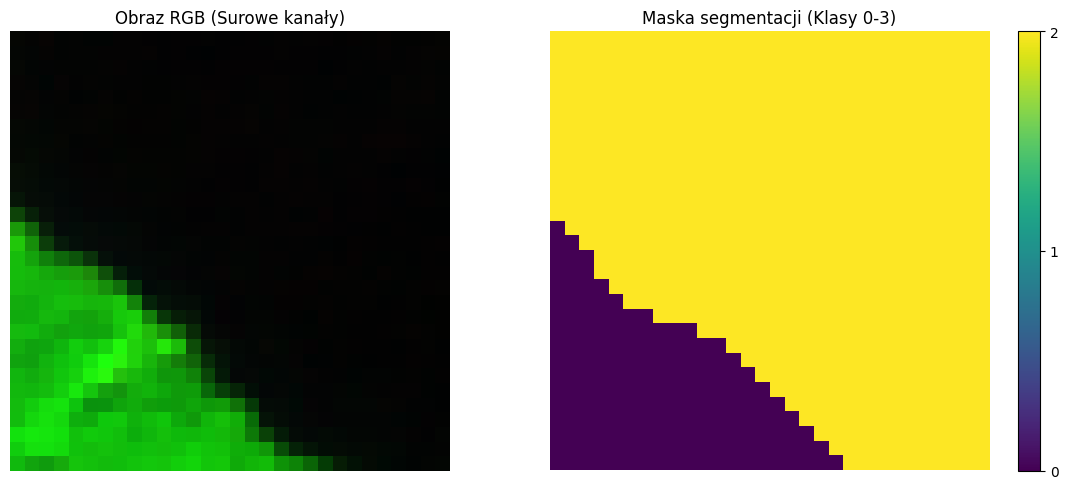

In [11]:
# Wizualizacja pierwszej próbki ze zbioru treningowego
import matplotlib.pyplot as plt

bands, mask = train_ds[0]

# Przekształcamy z formatu [C, H, W] na [H, W, C] dla matplotlib
bands_np = bands.permute(1, 2, 0).numpy()
mask_np = mask.numpy()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Wizualizacja obrazu - wybieramy np. kanały 4, 3, 2 dla RGB
img_to_show = bands_np[:, :, [3, 2, 1]] 
img_to_show = (img_to_show - img_to_show.min()) / (img_to_show.max() - img_to_show.min())
ax[0].set_title(f"Obraz RGB (Surowe kanały)")

ax[0].imshow(img_to_show)
ax[0].axis('off')

# Wizualizacja maski segmentacji
im_mask = ax[1].imshow(mask_np, cmap='viridis')
ax[1].set_title(f"Maska segmentacji (Klasy 0-3)")
ax[1].axis('off')

plt.colorbar(im_mask, ax=ax[1], ticks=[0, 1, 2, 3])    
plt.tight_layout()
plt.show()

In [12]:
# Sprawdzenie kształtu danych wejściowych (rozmiar, liczba kanałów)
bands, mask = train_ds[0]
print(f"Kształt danych wejściowych (pasma): {bands.shape}")
print(f"Kształt danych wejściowych (maska): {mask.shape}")

Kształt danych wejściowych (pasma): torch.Size([12, 30, 30])
Kształt danych wejściowych (maska): torch.Size([30, 30])


### 1.2 Walidacja danych

Po wstępnej eksploracji podstawowych właściwości danych, przeprowadzimy walidację danych treningowych i walidacyjnych, aby upewnić się, że są one odpowiednie do dalszej analizy i modelowania. Weryfikacja skupia się na porównaniu rozkładów zmiennej celu w zbiorach danych, a także sprawdzeniu braków danych.

In [13]:
# Sprawdzenie braków danych w zbiorze treningowym i walidacyjnym
def check_missing_data(dataset):
    missing_bands = []
    for idx in range(len(dataset)):
        bands, _ = dataset[idx]
        if torch.isnan(bands).any():
            missing_bands.append(idx)
    
    if missing_bands:
        print(f"Brakujące dane w próbkach: {missing_bands}")
    else:
        print("Brak brakujących danych w zbiorze.")

print("Sprawdzanie braków danych w zbiorze treningowym:")
check_missing_data(train_ds)
print("\nSprawdzanie braków danych w zbiorze walidacyjnym:")
check_missing_data(val_ds)

Sprawdzanie braków danych w zbiorze treningowym:
Brak brakujących danych w zbiorze.

Sprawdzanie braków danych w zbiorze walidacyjnym:
Brak brakujących danych w zbiorze.


In [14]:
# Sprawdzenie rozkładu klas w zbiorze treningowym i walidacyjnym
def check_class_distribution(dataset):
    class_counts = np.zeros(4, dtype=int)
    for idx in range(len(dataset)):
        _, mask = dataset[idx]
        for c in range(4):
            class_counts[c] += (mask == c).sum().item()

    total_pixels = class_counts.sum()
    print(f"Rozkład klas (liczba pikseli): {class_counts}")
    print(f"Rozkład klas (procentowo): {np.round(class_counts / total_pixels * 100)}")
print("Rozkład klas w zbiorze treningowym:")
check_class_distribution(train_ds)
print("\nRozkład klas w zbiorze walidacyjnym:")
check_class_distribution(val_ds)

Rozkład klas w zbiorze treningowym:
Rozkład klas (liczba pikseli): [12049 11348 13384  6419]
Rozkład klas (procentowo): [28. 26. 31. 15.]

Rozkład klas w zbiorze walidacyjnym:
Rozkład klas (liczba pikseli): [4666 1943 5044 2747]
Rozkład klas (procentowo): [32. 13. 35. 19.]


### 1.3 Analiza danych

Przyjrzymy się bliżej danym satelitarnym jakimi dysponujemy w tym zadaniu. Do dyspozycji mamy 12 kanałów, które reprezentują różne długości fal świetlnych. Każdy kanał zawiera informacje o odbiciu światła od powierzchni Ziemi w określonym zakresie spektralnym. Aby uzyskać maksymalną liczbę punktów za zadanie, musimy zredukować liczbę kanałów do 3. Oznacza to, że musimy znaleźć sposób na wybranie lub przekształcenie tych 12 kanałów w taki sposób, aby zachować jak najwięcej informacji przy jednoczesnym ograniczeniu ich liczby.
Do analizy danych wykorzystamy szereg wizualizacji, które pozwolą nam zrozumieć naturę wszystkich pasm.

In [15]:
# Przygotowanie danych do analizy - spłaszczenie danych do formatu pandas DataFrame
import pandas as pd
import seaborn as sns

all_pixels = []
class_names = {0: "Woda", 1: "Ląd", 2: "Roślinność", 3: "Tereny przemysłowe"}

for i in range(len(train_ds)):
    img, mask = train_ds[i]
    c = img.shape[0]
    # Spłaszczenie pikseli
    pixels = img.permute(1, 2, 0).reshape(-1, c).numpy()
    labels = mask.reshape(-1).numpy()
    
    # Filtrowanie i zbieranie danych
    valid_indices = labels != -1
    for p, l in zip(pixels[valid_indices], labels[valid_indices]):
        all_pixels.append(list(p) + [class_names[l]])
        
df_eda = pd.DataFrame(all_pixels, columns=[f"B{i+1}" for i in range(12)] + ["Klasa"])

Wpierw, sprawdźmy wpływ każdego z pasm na poszczególne klasy. Poniższy zestaw wykresów typu boxplot pozwoli lepiej zrozumieć, jak poszczególne kanały pozwalają rozróżniać rozważane cztery klasy.

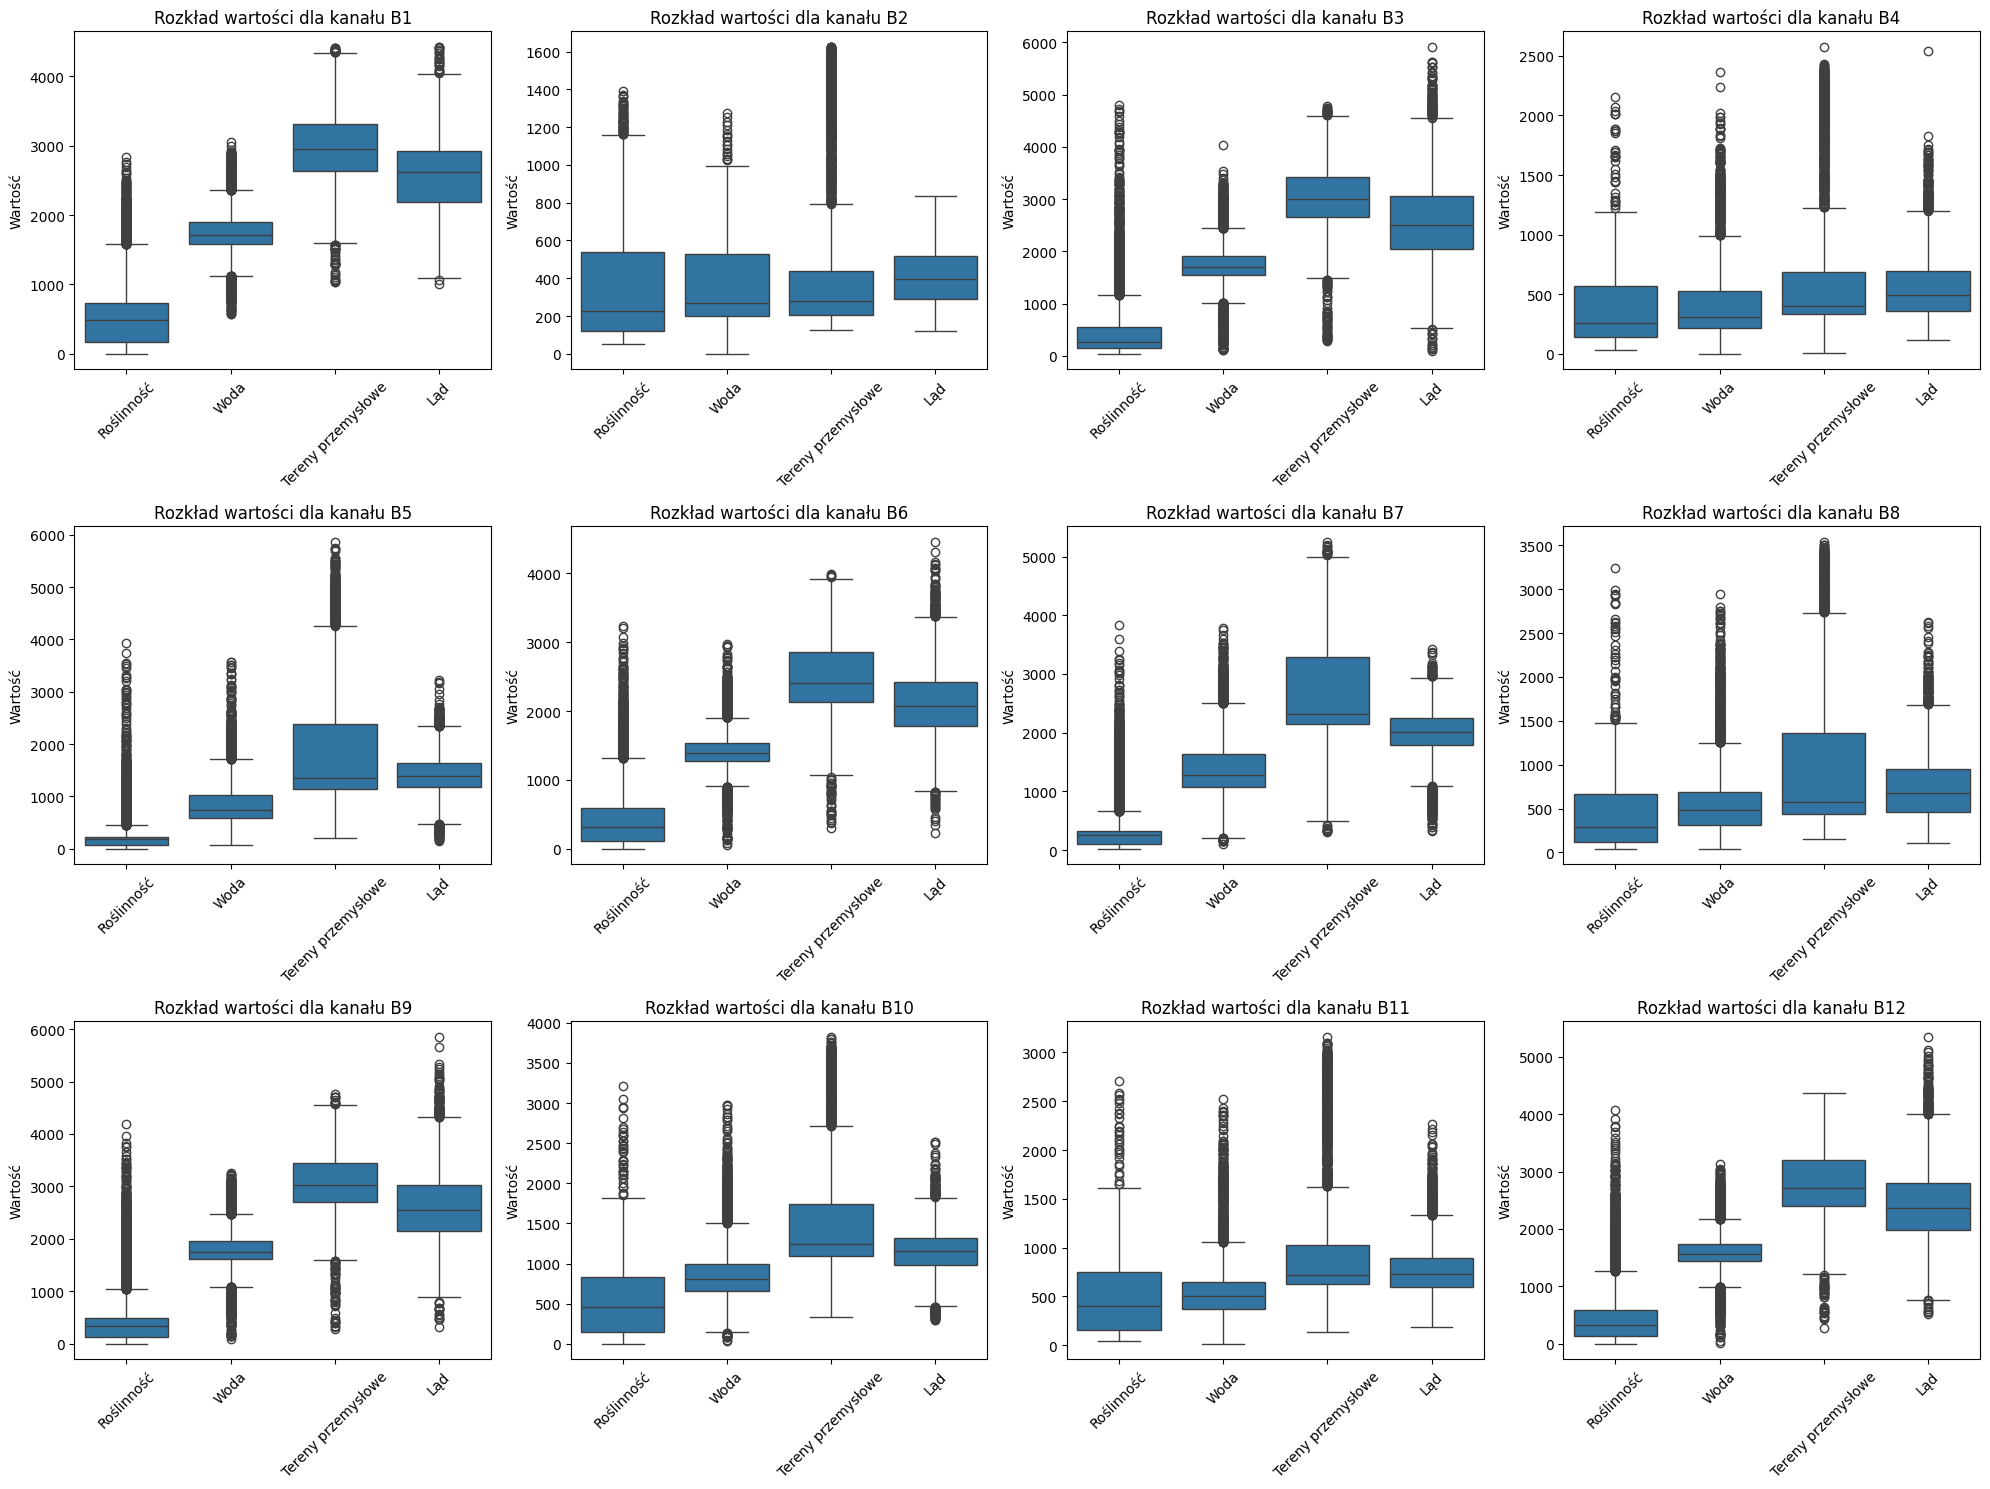

In [16]:
# Wizualizacja wpływu klasy na rozkład wartości w poszczególnych kanałach spektralnych
plt.figure(figsize=(20, 15))
for i in range(1, 13):
    plt.subplot(3, 4, i)
    sns.boxplot(x='Klasa', y=f'B{i}', data=df_eda, legend=False)
    plt.title(f'Rozkład wartości dla kanału B{i}')
    plt.xticks(rotation=45)
    plt.ylabel('Wartość')
    plt.xlabel('')
plt.tight_layout()
plt.show()

Z wykresów wynika, że niektóre pasma w znacznym stopniu pozwalają rozgraniczyć klasy (na przykład, *B1* i *B7*), podczas gdy niektóre kanały osiągają zbliżone wartości niezależnie od terenu - przykładowo kanały *B2* i *B4*. To pierwsza sugestia do tego, że prawdopodobnie nie potrzebujemy całego zestawu danych wejściowych, aby skutecznie przeprowadzić segmentację wielospektralną.

Przyjrzyjmy się teraz, jak wizualnie różnią się kanały między sobą.

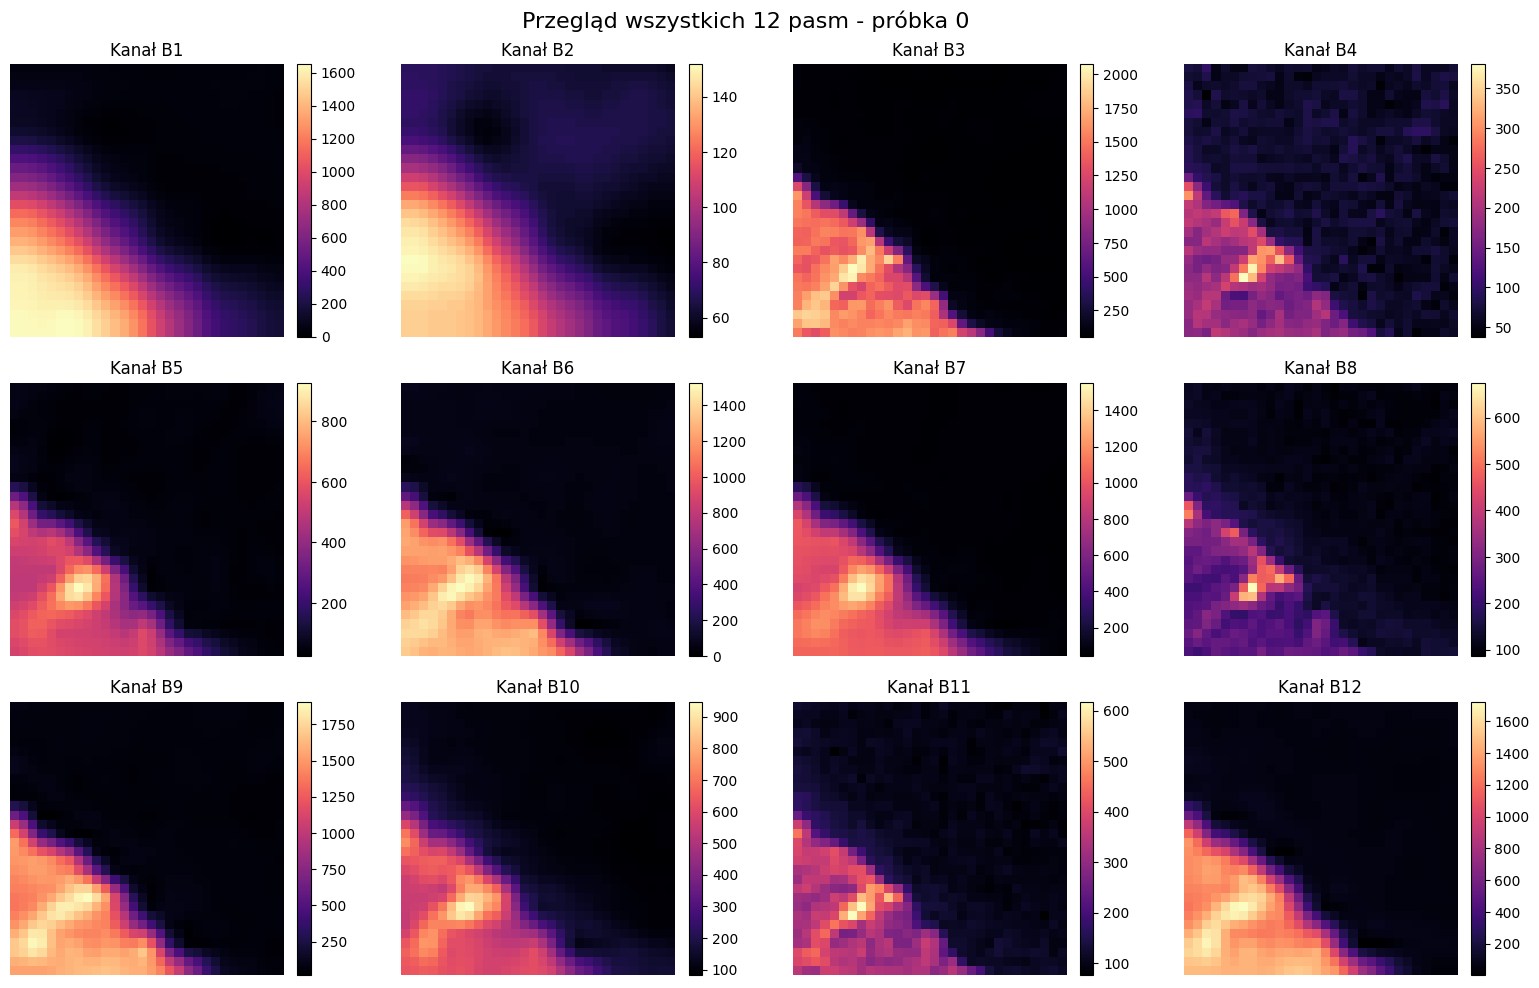

In [17]:
# Wizualizacja wszystkich 12 pasm dla pierwszej próbki ze zbioru treningowego
def plot_all_bands(dataset: torch.utils.data.Dataset, idx = 0):
    bands, _ = dataset[idx]
    _, axes = plt.subplots(3, 4, figsize=(16, 10))
    axes = axes.flatten()

    for i in range(12):
        band_data = bands[i].numpy()
        im = axes[i].imshow(band_data, cmap='magma')
        axes[i].set_title(f"Kanał B{i+1}")
        axes[i].axis('off')
        plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

    plt.suptitle(f"Przegląd wszystkich 12 pasm - próbka {idx}", fontsize=16)
    plt.tight_layout()
    plt.show()

plot_all_bands(train_ds, idx=0)

Już na pierwszy rzut oka możemy dostrzec pewne podobieństwa pomiędzy poszczególnymi pasmami. Na przykład, kanały $B6$ i $B9$ łudząco przypominają siebie nawzajem. To oczywiście jedynie poglądowe spostrzeżenia, które można powielić na większej liczbie próbek. 

Żeby się utwierdzić co do podobieństw między pasmami, zbadamy miarę korelacji pomiędzy każdą parą. Aby to zwizualizować w przystępny sposób, posłużymy się tzw. mapą ciepła (*heatmap*), gdzie pasma tworzą macierz $12 \times 12$, a wartości w komórkach macierzy to współczynniki korelacji Pearsona. Jest to miara podobieństwa określająca poziom liniowej zależności między zmiennymi losowymi, dana wzorem:
$$
\rho(X, Y) = \frac{\text{cov}(X, Y)}{\sigma_X \sigma_Y} \in [-1, 1]
$$
Gdzie $\text{cov}(X, Y)$ to kowariancja między pasmami $X$ i $Y$, natomiast $\sigma_X, \sigma_Y$ to ich odchylenia standardowe.

Im bliżej wartości 1 lub -1, tym większa liniowa zależność między parą kanałów (odpowiednio dodatnia lub ujemna), zatem tym większy argument do usunięcia jednego z nich lub zastosowania metod redukcji wymiarowości. Wartości bliskie zeru oznaczają brak zależności liniowej, co sugeruje, że każde z takich pasm wnosi do modelu unikalną informację. 

Analiza macierzy korelacji pozwoli nam zidentyfikować grupy pasm, które są ze sobą silnie powiązane. Na mapie ciepła wysokie wartości korelacji objawiać się będą jako bloki o intensywnym kolorze (w tym przypadku, ciemnoczerwonym), co pozwoli na natychmiastową, wizualną segmentację pasm niosących podobną informację spektralną.

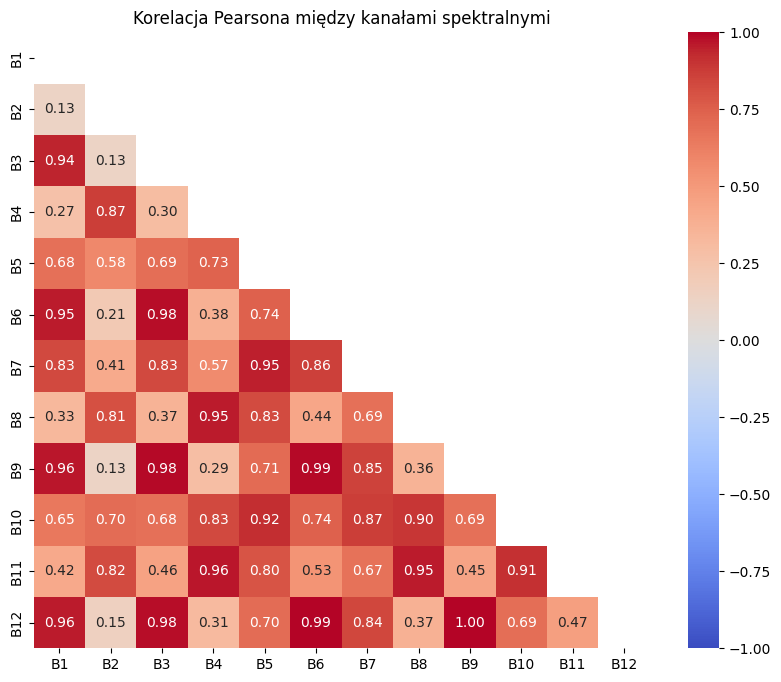

In [18]:
# Macierz korelacji kanałów spektralnych
plt.figure(figsize=(10, 8))
corr = df_eda.drop(columns="Klasa").corr()
# Zachowujemy tylko dolną trójkątną część macierzy korelacji, aby uniknąć powtórzeń informacji (korelacja jest symetryczna)
mask = np.triu(np.ones_like(corr, dtype=bool))
corr = corr.mask(mask)

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True, vmin=-1, vmax=1)
plt.title("Korelacja Pearsona między kanałami spektralnymi")
plt.show()

Patrząc na mapę ciepła, zauważmy znaczną liczbę wysokich współczynników korelacji. Komórki w kolorze bliskim do ciemnoczerwonego (o wartości korelacji bliskiej 1.0) sugerują pary, w których następuje silna liniowa zależność. Aby łatwiej scharakteryzować podobne skupiska pasm, zastosujemy kolejną wizualizację danych - dendrogram. Jest to hierarchiczne grupowanie pasm na podstawie podobieństwa - tu korelacji.

<a id="dendrogram-sekcja"></a>
### Wizualizacja dendrogramu grupowania kanałów spektralnych

<Figure size 1000x800 with 0 Axes>

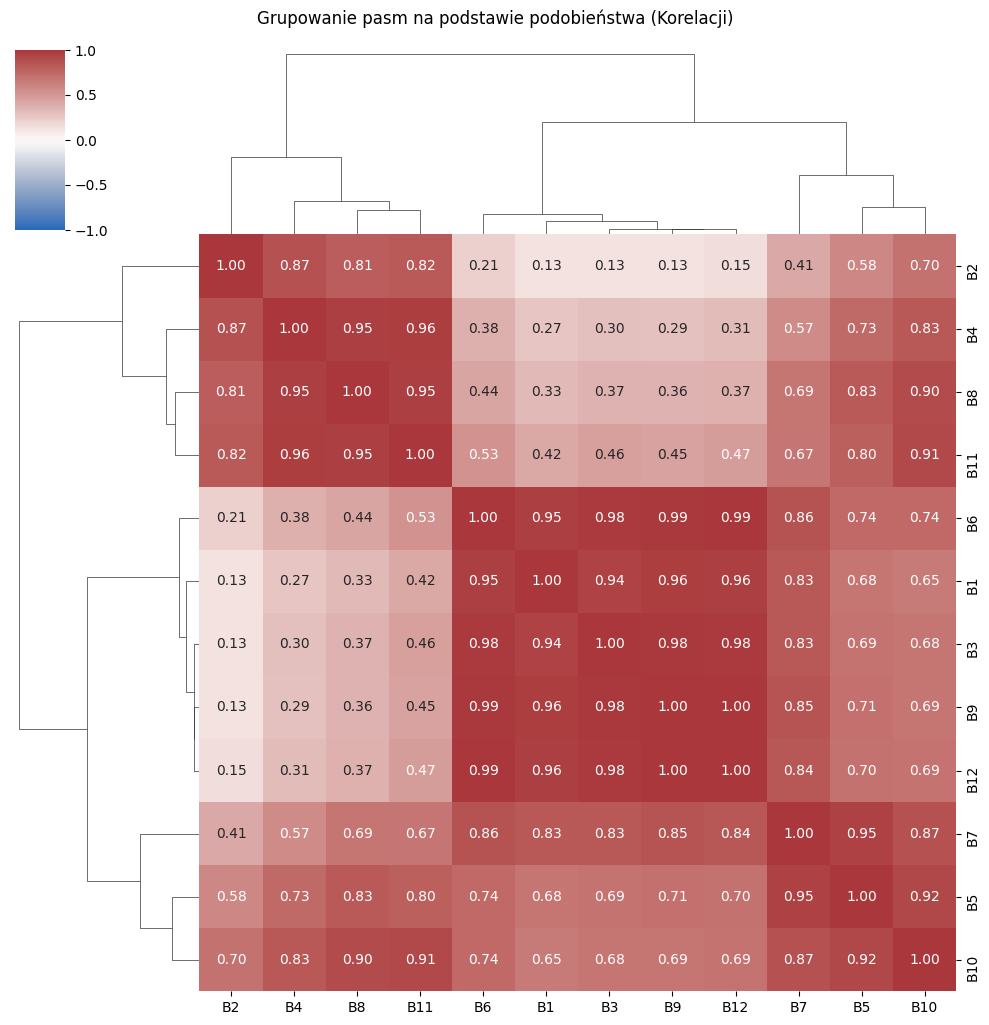

In [19]:
plt.figure(figsize=(10, 8))
# Wybieramy tylko kolumny z pasmami
band_cols = [f"B{i+1}" for i in range(12)]
corr = df_eda[band_cols].corr()

# Cluster map grupuje podobne kanały obok siebie
g = sns.clustermap(corr, annot=True, fmt=".2f", cmap='vlag', 
                    figsize=(10, 10), vmin=-1, vmax=1)
g.figure.suptitle("Grupowanie pasm na podstawie podobieństwa (Korelacji)", y=1.02)
plt.show()

Analiza klastrowa (dendrogram) macierzy korelacji ujawniła, że 12 kanałów wejściowych de facto można pogrupować w trzy wyraźne bloki informacyjne o bardzo wysokiej korelacji wewnętrznej (często przekraczającej 0.95). Potwierdza to hipotezę o silnej redundancji danych multispektralnych i stanowi bezpośrednie uzasadnienie dla zastosowania redukcji wymiarowości.

## 2. Inżynieria cech

Po analizie zależności między pasmami oraz ich wpływie na poszczególne klasy, skupimy się na selekcji pasm i inżynierii cech. Na podstawie analizy korelacji możemy stwierdzić, że wybranie 3 najbardziej informacyjnych pasm może być dobrym punktem wyjścia. Natomiast, jeszcze lepszym rozwiązaniem może być stworzenie nowych cech, które łączą informacje z kilku pasm, tak aby każde z nich miało swoją reprezentację. Taką metodą jest **Analiza Głównych Składowych** (*Principal Component Analysis - PCA*).

### 2.1 Analiza głównych składowych  (Principal Component Analysis)

Principal Component Analysis (PCA) to technika redukcji wymiarów, która pozwala zidentyfikować najważniejsze kierunki wariancji w danych. Matematycznie PCA polega na transformacji liniowej, która rzutuje dane na nowy układ współrzędnych w trzech etapach:

1. Każde z 12 pasm poddawane jest procesowi standaryzacji ($z_i = \frac{x_i-\mu_i}{\sigma_i}, \forall i \in \lbrace 1, ..., 12 \rbrace$), aby różnice w zakresach wartości poszczególnych kanałów nie wpływały na wynik analizy.

2. Na podstawie wystandaryzowanych danych obliczana jest macierz kowariancji, która liczbowo opisuje zależności pomiędzy pasmami (odzwierciedla ona korelacje widoczne na dendrogramie). Na jej podstawie oblicza się wektory własne, które wyznaczają nowe, prostopadłe kierunki (osie) danych, oraz odpowiadające im wartości własne, określające siłę wariancji wzdłuż tych osi.

3. Główne składowe powstają poprzez rzutowanie danych na wyznaczone wektory własne. Pierwsza składowa wyjaśnia jak największą część całkowitej wariancji, a każda kolejna największą pozostałą część informacji, pozostając całkowicie nieskorelowaną z poprzednimi (dzięki symetryczności macierzy kowariancji, jej wektory własne są względem siebie ortogonalne).

W kontekście danych multispektralnych, PCA pozwala zredukować liczbę kanałów wejściowych przy minimalnej utracie informacji. Jest to szczególnie istotne w przypadku satelitarnych obrazów 12-pasmowych, gdzie – jak wykazała analiza korelacji na dendrogramie – występuje wiele powielanych informacji. Sprawdźmy, jak kompresja wejściowych danych do 3 głównych składowych wpłynie na zachowanie informacji - to znaczy, jaki procent wariancji wejściowych danych będzie wyjaśniony przez transformację do 3 najważniejszych głównych składowych PCA.

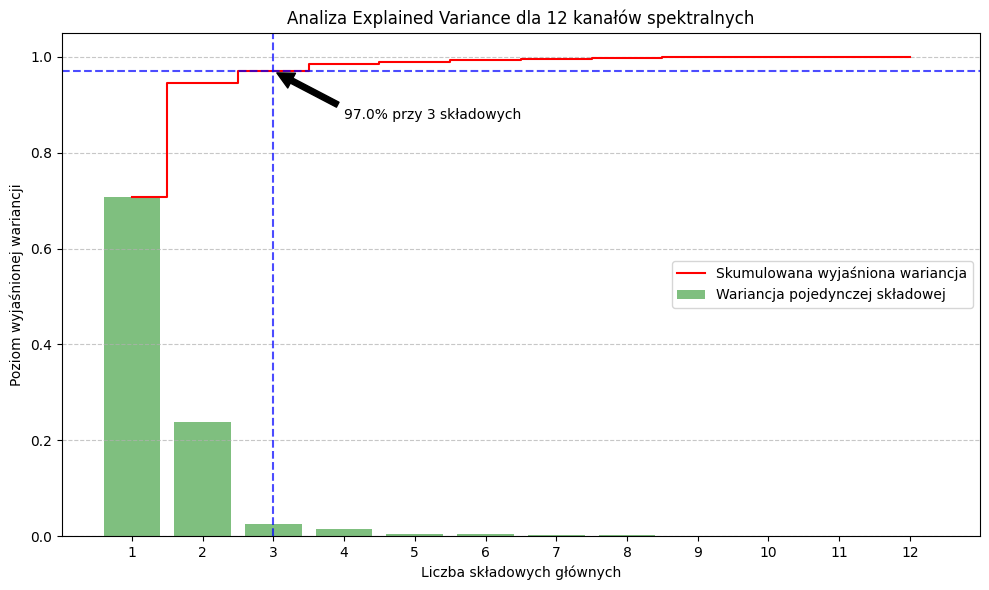

In [20]:
# Wizualizacja explained variance (wyjaśnionej wariancji w danych) dla 12 kanałów spektralnych
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

band_cols = [f"B{i+1}" for i in range(12)]
X = df_eda[band_cols].values

# Standaryzacja
X_scaled = StandardScaler().fit_transform(X)

# Dopasowanie PCA dla wszystkich możliwych komponentów
pca = PCA(n_components=12)
pca.fit(X_scaled)

# Obliczanie wariancji
exp_var_pca = pca.explained_variance_ratio_
cum_sum_eigenvalues = np.cumsum(exp_var_pca)

# Wizualizacja
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(range(1, 13), exp_var_pca, alpha=0.5, align='center',
        label='Wariancja pojedynczej składowej', color='g')

ax1.step(range(1, 13), cum_sum_eigenvalues, where='mid',
            label='Skumulowana wyjaśniona wariancja', color='r')

# Dodanie linii pomocniczej dla Twoich 3 komponentów
variance_3 = cum_sum_eigenvalues[2]
ax1.axvline(x=3, color='blue', linestyle='--', alpha=0.7)
ax1.axhline(y=variance_3, color='blue', linestyle='--', alpha=0.7)

plt.annotate(f'{variance_3*100:.1f}% przy 3 składowych', 
                xy=(3, variance_3), xytext=(4, variance_3-0.1),
                arrowprops=dict(facecolor='black', shrink=0.05))

plt.ylabel('Poziom wyjaśnionej wariancji')
plt.xlabel('Liczba składowych głównych')
plt.title('Analiza Explained Variance dla 12 kanałów spektralnych')
plt.xticks(range(1, 13))
plt.legend(loc='center right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Pierwszy etap zadania polega na redukcji liczby kanałów wejściowych do modelu. Aby osiągnąć maksymalną liczbę punktów za tę część zadania, powinniśmy ograniczyć się do 3 kanałów. Wykorzystując PCA, możemy zredukować liczbę kanałów spektralnych do 3, zachowując jednocześnie większość informacji zawartej w oryginalnych 12 kanałach (około 97% wyjaśnionej wariancji).

### 2.2 Augmentacja danych

Wejściowy zbiór treningowy ma zaledwie 48 obrazów. Aby zmaksymalizować sukces modelu, warto zastosować techniki augmentacji danych, które pozwolą na sztuczne zwiększenie różnorodności danych treningowych:
- **Rotacja**: Obracanie obrazów o losowe kąty (np. 90°, 180°, 270°) może pomóc modelowi nauczyć się rozpoznawać obiekty niezależnie od orientacji.
- **Odbicie**: Odbicia lustrzane w poziomie i pionie mogą zwiększyć różnorodność danych, szczególnie jeśli obiekty na obrazach nie mają określonej orientacji.

Przy ustalaniu parametrów ważne jest zachowanie realizmu. Unikamy drastycznych deformacji czy losowego przycinania, które mogłoby usunąć kluczowe obiekty przy tak małym rozmiarze obrazów wejściowych.

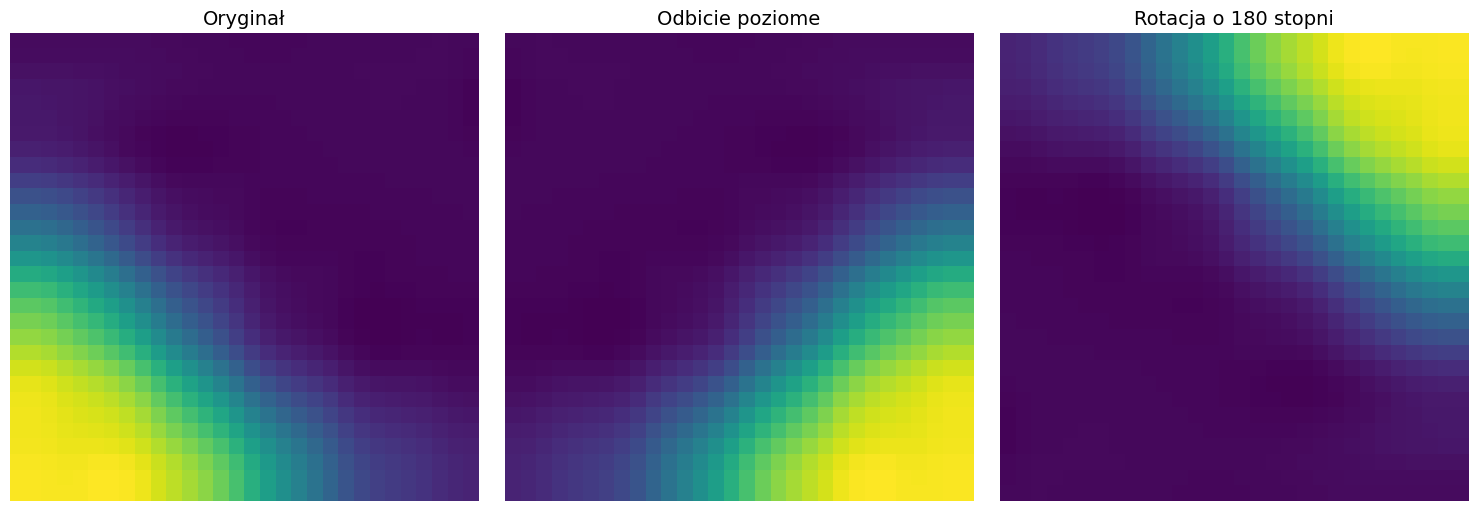

In [21]:
# Przykładowa próbka ze zbioru treningowego
sample_img, _ = train_ds[0]

# Funkcja pomocnicza do normalizacji i przygotowania obrazu do wyświetlenia
def get_printable_img(tensor):
    img = tensor[0].numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return img

# Odbicie poziome (ostatnia oś - szerokość)
img_hflipped = torch.flip(sample_img, dims=[-1])

# Rotacja o 180 stopni
img_rotated = torch.rot90(sample_img, k=2, dims=[-2, -1])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

augmentations = [
    (sample_img, "Oryginał"),
    (img_hflipped, "Odbicie poziome"),
    (img_rotated, "Rotacja o 180 stopni"),
]

for i, (img_tensor, title) in enumerate(augmentations):
    axes[i].imshow(get_printable_img(img_tensor), cmap='viridis')
    axes[i].set_title(title, fontsize=14)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 3. Architektura modelu

Rdzeniem zaproponowanego modelowego rozwiązania jest konwolucyjna sieć neuronowa. W następnych podsekcjach zostaną dokładnie omówione poszczególne komponenty architektury modelu.

### 3.1 Warstwy konwolucyjne

Głównym zadaniem warstw konwolucyjnych (splotowych) w niniejszym zadaniu jest automatyczna ekstrakcja cech przestrzennych i spektralnych z trzech składowych głównych otrzymanych po transformacji PCA.

Podstawową operacją tej warstwy jest konwolucja (splot) – operacja matematyczna, która skupia się na lokalnym sąsiedztwie pikseli. Proces ten definiują trzy główne parametry:

*   **Filtr / jądro (*kernel*)** – macierz wag przesuwająca się nad obrazem wejściowym. Definiuje ona rozmiar okna, wewnątrz którego model wykrywa zależności przestrzenne (np. krawędzie między wodą a lądem).
*   **Krok (*stride*)** – liczba pikseli, o którą przesuwa się filtr. W tym modelu zastosowano stały krok równy 1, co pozwala na zachowanie pełnej rozdzielczości przestrzennej, niezbędnej do precyzyjnej segmentacji każdego piksela.
*   **Wypełnienie (*padding*)** – dodanie ramki o wartości 0 wokół krawędzi obrazu. Dzięki zastosowaniu paddingu równego 1 przy jądrze $3 \times 3$, wymiary mapy cech po operacji konwolucji pozostają identyczne z wymiarami wejściowymi. Jest to kluczowe, aby finalna maska segmentacji dokładnie pokrywała się z obrazem satelitarnym.

Dla wejściowego obrazu $I$ oraz macierzy filtru $K$ o rozmiarze $(m \times n)$, wartość w punkcie $(i, j)$ mapy cech wyjściowej $S$ obliczana jest według wzoru:
$$S(i, j) = (I * K)(i, j) = \sum_{m} \sum_{n} I(i+m, j+n) \cdot K(m, n)$$

W opracowanej architekturze `YourModel` zastosowano specyficzny układ warstw, zoptymalizowany pod kątem ekstrakcji cech przy ograniczonej liczbie próbek:

1.  **Warstwa conv1**: 64 filtry o rozmiarze $3 \times 3$ (padding 1, stride 1). Przyjmuje 3 kanały PCA i przekształca je w bogatszą reprezentację cech niskopoziomowych, np. krawędzi zorientowanych w różnych kierunkach.
2.  **Warstwa conv2**: 128 filtrów o rozmiarze $3 \times 3$ (padding 1, stride 1). Jest to najgłębsza warstwa modelu, pozwalająca na uchwycenie szerokiego kontekstu przestrzennego.
3.  **Warstwa conv3**: Redukcja do 64 filtrów o rozmiarze $3 \times 3$ (padding 1, stride 1). Przygotowuje dane do finalnej klasyfikacji, agregując wyekstrahowane wzorce.
4.  **Warstwa classifier**: Konwolucja typu *pointwise* (rozmiar $1 \times 1$, bez paddingu) z 4 kanałami wyjściowymi. Pełni ona rolę klasyfikatora dla każdego piksela z osobna, zwracając logity dla czterech zdefiniowanych klas terenu (Woda, Ląd, Roślinność, Przemysł).

Po każdej operacji konwolucji stosowana jest nieliniowa funkcja aktywacji **ReLU (Rectified Linear Unit)**, która pozwala sieci uczyć się złożonych, nieliniowych zależności w danych spektralnych:
$$
ReLU(x) = \max(0, x)
$$
W poniższym fragmencie kodu wykorzystane są jedynie warstwy konwolucyjne z funkcjami aktywacji, bez warstw batch normalization. Ich wpływ zobrazujemy w następnej sekcji. Poniższe wizualizacje mają charakter **poglądowy** – ponieważ wagi modelu są zainicjalizowane losowo, mapy cech nie posiadają jeszcze interpretacji semantycznej (nie rozpoznają konkretnych obiektów). Ich celem jest jednak ukazanie krytycznego znaczenia architektury sieci dla stabilności sygnału.

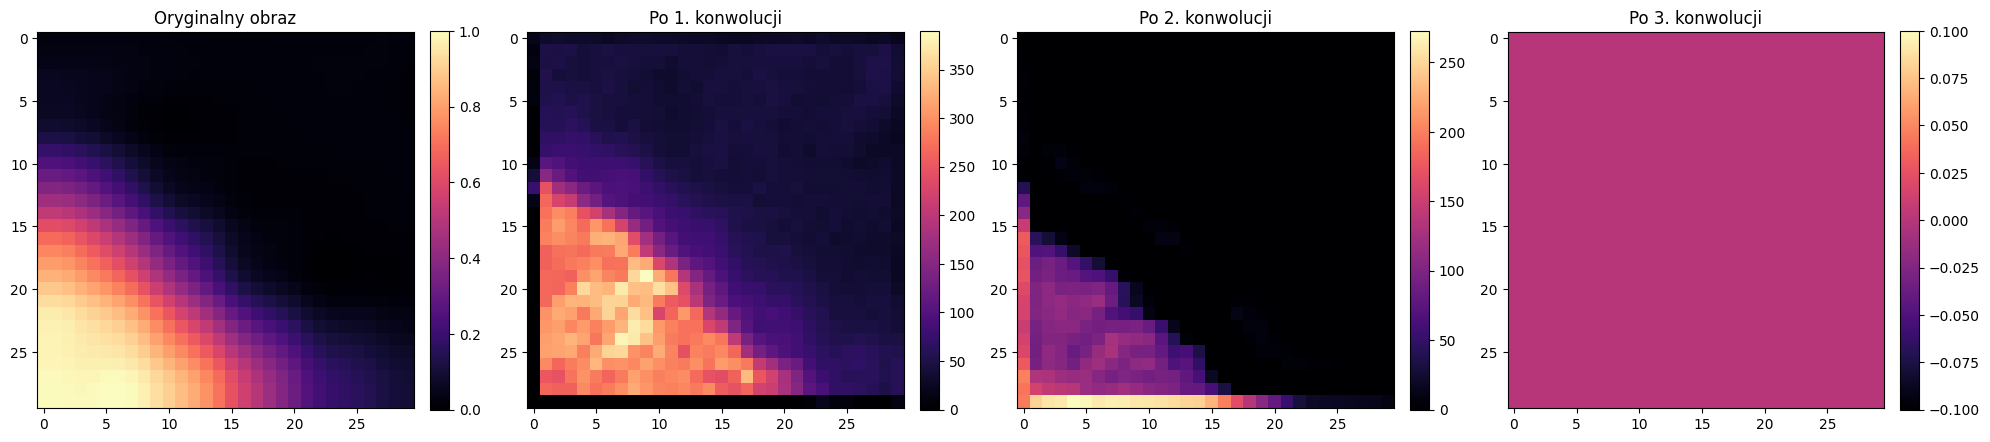

In [22]:
# Przygotowanie danych (wymiary [1, 12, H, W])
sample_img, _ = train_ds[0]
x_input = sample_img.unsqueeze(0)

conv1 = nn.Conv2d(in_channels=12, out_channels=64, kernel_size=3, padding=1)
conv2 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
conv3 = nn.Conv2d(in_channels=128, out_channels=64, kernel_size=3, padding=1)

with torch.no_grad():
    res1 = torch.relu(conv1(x_input))
    res2 = torch.relu(conv2(res1))
    res_relu_only = torch.relu(conv3(res2))

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

im_orig = axes[0].imshow(get_printable_img(sample_img), cmap='magma')
axes[0].set_title("Oryginalny obraz")
plt.colorbar(im_orig, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(res1[0, 0].cpu(), cmap='magma')
axes[1].set_title("Po 1. konwolucji")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(res2[0, 0].cpu(), cmap='magma')
axes[2].set_title("Po 2. konwolucji")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

im3 = axes[3].imshow(res_relu_only[0, 0].cpu(), cmap='magma')
axes[3].set_title("Po 3. konwolucji")
plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

W tym scenariuszu dane są przetwarzane bezpośrednio przez kolejne filtry splotowe i funkcję nieliniową. Możemy zaobserwować dwa niekorzystne zjawiska:

1. **Dryf i eksplozja zakresów**: Jak wskazują paski skali, wartości aktywacji gwałtownie zmieniają swoją amplitudę – od rzędu setek po pierwszej konwolucji, do ułamkowych wartości w kolejnych. Brak kontroli nad wariancją utrudnia stabilizację procesu uczenia.

2. **Zjawisko *Dying ReLU***: Na ostatnim etapie wizualizacji mapa cech staje się całkowicie jednolita (wartości zerowe). Wynika to z faktu, że bez normalizacji, losowo przemnożony sygnał spadł poniżej zera, co spowodowało "zablokowanie" neuronów przez funkcję ReLU. W tej konfiguracji model traci zdolność do przekazywania informacji do głębszych warstw, co uniemożliwia efektywny trening.

### 3.2 Warstwy normalizacji

Warstwy Batch Normalization (BatchNorm) zostały zaimplementowane w modelu po każdej operacji konwolucji, przed warstwą aktywacji ReLU. Ich głównym zadaniem jest stabilizacja i przyspieszenie procesu uczenia poprzez standaryzację aktywacji wewnątrz sieci.

W kontekście segmentacji obrazów satelitarnych, gdzie wartości spektralne mogą się znacznie różnić między próbkami, BatchNorm pełni kluczową rolę w utrzymaniu spójności danych przepływających przez głębokie warstwy sieci. Proces ten opiera się na następujących krokach:

*   **Normalizacja**: Dla każdego kanału w bieżącej paczce danych (*batch*), warstwa oblicza średnią oraz odchylenie standardowe, a następnie centruje i przeskalowuje dane tak, aby miały średnią bliską 0 i wariancję bliską 1.
*   **Skalowanie i przesunięcie (*learnable parameters*)**: Po normalizacji, warstwa wprowadza dwa parametry uczalne – $\gamma$ (gamma) oraz $\beta$ (beta). Pozwalają one sieci na przywrócenie pierwotnej skali danych, jeśli model uzna, że jest to niezbędne dla poprawnego rozpoznania cech terenu.


Warstwy BatchNorm zawierają również parametr **momentum**. Parametr ten określa, w jakim stopniu statystyki z bieżącej paczki danych wpływają na średnią kroczącą całego zbioru. W modelowym rozwiązaniu zastosowano niską wartość `momentum=0.01`, co jest kluczowe przy bardzo małym zbiorze treningowym (48 próbek), ponieważ zapobiega zbyt gwałtownym zmianom wag i stabilizuje proces optymalizacji.
Sprawdźmy, jak zmieni się wygląd danych przetworzonych przez warstwę BatchNorm, po konwolucji:

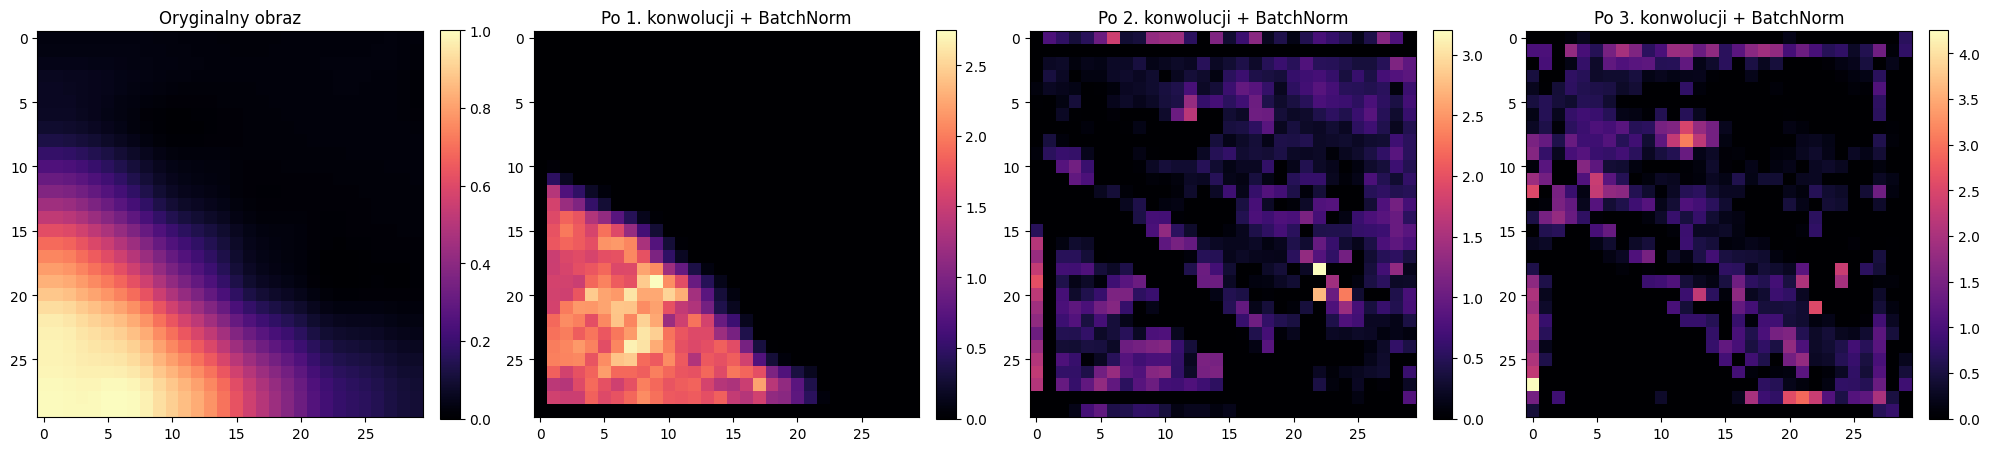

In [23]:
# 3 Warstwy z Batch Normalization
bn1 = nn.BatchNorm2d(64, momentum=0.01)
bn2 = nn.BatchNorm2d(128, momentum=0.01)
bn3 = nn.BatchNorm2d(64, momentum=0.01)

with torch.no_grad():
    # Używamy tej samej mapy cech dla rzetelnego porównania
    res_bn_1 = torch.relu(bn1(res1))
    res_bn_2 = torch.relu(bn2(conv2(res_bn_1)))
    res_bn_relu = torch.relu(bn3(conv3(res_bn_2)))
    

# Wizualizacja
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

im_orig = axes[0].imshow(get_printable_img(sample_img), cmap='magma')
axes[0].set_title(f"Oryginalny obraz")
plt.colorbar(im_orig, ax=axes[0], fraction=0.046, pad=0.04)

im_bn1 = axes[1].imshow(res_bn_1[0, 0].cpu(), cmap='magma')
axes[1].set_title("Po 1. konwolucji + BatchNorm")
plt.colorbar(im_bn1, ax=axes[1], fraction=0.046, pad=0.04)
im_bn2 = axes[2].imshow(res_bn_2[0, 0].cpu(), cmap='magma')
axes[2].set_title("Po 2. konwolucji + BatchNorm")
plt.colorbar(im_bn2, ax=axes[2], fraction=0.046, pad=0.04)
im_bn3 = axes[3].imshow(res_bn_relu[0, 0].cpu(), cmap='magma')
axes[3].set_title("Po 3. konwolucji + BatchNorm")
plt.colorbar(im_bn3, ax=axes[3], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Zastosowanie Batch Normalization w architekturze segmentacyjnej przynosi wymierne korzyści: 

- **Stabilizacja**: Dzięki centrowaniu i skalowaniu danych, wartości na każdym etapie pozostają w optymalnym zakresie (w tym przypadku $[0, 4]$). Zapobiega to drastycznym zmianom rozkładu danych w głębszych warstwach, co umożliwia zachowanie stabilnych gradientów niezbędnych do nauki.

- **Eliminacja zjawiska *Dying ReLU***: BN gwarantuje drożność kanałów komunikacji w sieci. Bez normalizacji sygnał często staje się ujemny, co trwale blokuje neurony ReLU. Dzięki BN mapy cech pozostają aktywne, pozwalając modelowi z czasem wykształcić detektory tekstur i klas terenu.

- **Regularyzacja**: Estymowanie statystyk na poziomie każdej paczki danych wprowadza do modelu niewielki szum. Działa on jak naturalny mechanizm regularyzacyjny, co drastycznie ogranicza ryzyko przeuczenia (overfittingu) przy tak małym zbiorze treningowym.

## 4. Klasy rozwiązania

W zadaniu należało zaimplementować dwie klasy:
- Klasa przygotowująca dane (`YourPreprocessing`) - odpowiadająca za redukcję liczby kanałów i przygotowanie danych do treningu modelu.
- Klasa modelu (`YourModel`) - odpowiadająca za segmentację obrazów multispektralnych, która powinna być w stanie przyjąć dane zredukowane do 3 kanałów i osiągnąć jak najwyższą wartość średniego *Intersection over Union (mean IOU)* na 4 klasach.

### 4.1 Etap I: Klasa `YourPreprocessing`

Klasa `YourPreprocessing` redukuje liczbę wejściowych pasm z 12 do 3, co jest kluczowe dla uzyskania maksymalnego wyniku za pierwszą część zadania. W implementacji wykorzystujemy analizę głównych składowych do znalezienia trzech głównych komponentów, które najlepiej zachowują informację zawartą w oryginalnych 12 kanałach. Klasa implmentuje następujące metody:

* `fit(self, dataset)` - dopasowuje model PCA do danych treningowych, obliczając główne komponenty na podstawie wszystkich próbek w zbiorze treningowym. Standaryzuje dane przed dopasowaniem, co jest kluczowe dla rzetelnego PCA.
* `transform(self, image_tensor)` - aplikuje wyuczoną transformację PCA do pojedynczego obrazu, redukując liczbę kanałów do 3.

In [24]:
class YourPreprocessing:
    """
    Klasa do redukcji wymiarowości 12 kanałów do 3 za pomocą PCA.
    Uwaga: Ta klasa może jedynie przetwarzać próbki, nie może korzystać z etykiet danych.
    Żadna metoda nie może też wykonywać segmentacji.
    """
    
    def __init__(self):
        self.pca: PCA = PCA(n_components=3)
        self.mean: np.ndarray = None
        self.std: np.ndarray = None

    def fit(self, dataset) -> 'YourPreprocessing':
        """Oblicza statystyki i dopasowuje PCA na podstawie całego zbioru treningowego."""
        all_pixels: list[torch.Tensor] = []
        for i in range(len(dataset)):
            img, _ = dataset[i]
            # Wypłaszczenie pikseli [12, 30, 30] -> [900, 12]
            all_pixels.append(img.permute(1, 2, 0).reshape(-1, 12))
        
        pixels_np = torch.cat(all_pixels, dim=0).numpy()
        
        # Standaryzacja kanałów przed PCA
        self.mean = pixels_np.mean(axis=0)
        self.std = pixels_np.std(axis=0) + 1e-6
        
        normalized = (pixels_np - self.mean) / self.std
        self.pca.fit(normalized)
        return self

    def transform(self, image_tensor: torch.Tensor) -> torch.Tensor:
        """Aplikuje wyuczoną transformację PCA do pojedynczego obrazu."""
        c, h, w = image_tensor.shape
        pixels = image_tensor.permute(1, 2, 0).reshape(-1, c).numpy()
        
        # Normalizacja i rzutowanie na 3 składowe główne
        pixels = (pixels - self.mean) / self.std
        pixels_pca = self.pca.transform(pixels)
        
        # Powrót do formatu tensora [3, H, W]
        output = torch.from_numpy(pixels_pca).float()
        return output.reshape(h, w, 3).permute(2, 0, 1)

### 4.2 Etap II: `Klasa YourModel`

Klasa `YourModel` musi implementować architekturę sieci neuronowej, która będzie trenowana na przetworzonych danych. Tak jak już wspomiano w sekcji 3, model opiera się na konwolucyjnych warstwach z normalizacją batch i funkcją aktywacji ReLU, konkretnie:
- 4 warstwy konwolucyjne (Conv2d) z odpowiednią liczbą filtrów i rozmiarami filtrów. Ostatnia warstwa pełni rolę klasyfikatora, który mapuje zestawy cech na klasy - dla każdego piksela.
- 3 warstwy normalizacji batch (BatchNorm2d) po pierwszych trzech warstwach konwolucyjnych. Parametr `momentum` ustawiono na 0.01, aby zapobiec przeuczeniu się przy małej liczbie obrazów w zbiorze treningowym.
- Funkcja aktywacji ReLU po każdej warstwie konwolucyjnej (poza ostatnią).

Klasa implementuje następujące metody:
- `__init__(self)`: Inicjalizuje wyżej wymienione warstwy sieci.
- `forward(self, x)`: Definiuje przekazywanie danych przez sieć.

In [25]:
class YourModel(nn.Module):
    """Sieć konwolucyjna z 4 warstwami konwolucyjnymi i BatchNorm do segmentacji multispektralnej."""
    
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64, momentum=0.01),
            nn.ReLU()
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128, momentum=0.01),
            nn.ReLU()
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64, momentum=0.01),
            nn.ReLU()
        )
        self.classifier = nn.Conv2d(64, 4, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x1 = self.conv1(x)
        x2 = self.conv2(x1)
        x3 = self.conv3(x2)
        return self.classifier(x3)

## 5. Cykl uczenia i ewaluacji

Proces wytwarzania modelu oparto na iteracyjnym cyklu uczenia nadzorowanego, w którym sieć optymalizowała swoje wagi na zbiorze treningowym, a jej zdolność do generalizacji była mierzona po każdej epoce na niezależnym zbiorze walidacyjnym.

### 5.1 Wybór hiperparametrów

Dobór parametrów sterujących procesem uczenia został podyktowany specyfiką danych multispektralnych:

* **Tempo uczenia (Learning Rate):** Określa wielkość kroku podczas aktualizacji wag. Przyjęto wartość **0.002**, która pozwala na stabilne schodzenie w kierunku minimum funkcji celu.
* **Optymalizator:** Wykorzystano nowoczesny algorytm optymalizacji **AdamW** (*ADAptive Moment estimation with Weight decay*), który stanowi usprawnienie klasycznego algorytmu [*Adam*](https://arxiv.org/abs/1412.6980). Kluczową cechą **AdamW** jest poprawne matematycznie rozdzielenie mechanizmu adaptacyjnego tempa uczenia od regularyzacji wag (*weight decay*). Pozwala to na skuteczniejsze zapobieganie przeuczeniu (overfittingowi) i zapewnia lepszą generalizację modelu, co jest kluczowe przy pracy na relatywnie małym zbiorze danych.
* **Funkcja kosztu** Zastosowano **Cross-Entropy Loss**; funkcja ta skutecznie minimalizuje różnicę między rozkładem prawdopodobieństwa przewidzianym przez model a rzeczywistymi etykietami pikseli obejmującymi 4 klasy terenu (*Woda, Ląd, Roślinność, Tereny Przemysłowe*).
* **Rozmiar batch size:** Batch size ustawiono na **16**, zapewniając stabilność obliczeń gradientowych przy efektywnym wykorzystaniu zasobów pamięciowych.
* **Harmonogram uczenia - `OneCycleLR`:** Zastosowano dynamiczny scheduler. Harmonogram ten symetrycznie dzieli proces uczenia na kluczowe fazy: 
    1. **Rozgrzewkę (warm-up)** - wartość parametru `pct_start` ustawiono na **$0.7$**, co oznacza, że przez pierwsze $70\%$ całkowitej liczby epok tempo uczenia stopniowo rośnie od wartości początkowej do zdefiniowanego maksimum ($0.002$). Pozwala to na stabilną, wstępną eksplorację przestrzeni wag i chroni model przed przedwczesnym utknięciem w nieoptymalnych minimach lokalnych.
    2. **Fazę maksymalnego LR** - po osiągnięciu maksimum w połowie cyklu, model przechodzi przez punkt zwrotny przyśpieszający naukę.
    3. **Fazę spadku (annealing)** - przez pozostałe $30\%$ czasu uczenia następuje stopniowe wygaszanie wartości *learning rate* w kierunku zera. Pozwala to sieci na precyzyjne "osiąść" w znalezionym minimum globalnym.
    
### 5.2 Augmentacja danych *w locie* (online augmentation)
Ze względu na architekturę potoku przetwarzania, augmentacja została zintegrowana bezpośrednio z pętlą treningową. W każdej epoce para (obraz, maska) poddawana była losowym transformacjom geometrycznym:
* Rotacja: Wybierana losowo spośród kątów $0^\circ$ (oryginalny obraz), $90^\circ, 180^\circ$ oraz $270^\circ$
* Odbicia: Z prawdopodobieństwem 50% stosowano odbicie lustrzane w osi poziomej. 

Takie podejście sprawia, że model rzadko otrzymuje identyczną próbkę danych w kolejnych epokach, co działa jako silny mechanizm regularyzacyjny, ograniczający ryzyko przeuczenia.

### 5.3 Wybór najlepszego modelu

W trakcie **300** epok treningu zastosowano strategię **zapisu punktu kontrolnego (*Checkpointing*)**. Zamiast polegać na parametrach z ostatniej iteracji, po każdej epoce obliczano wynik *mean Intersection over Union (mIoU)* na zbiorze walidacyjnym. W pamięci przechowywany był stan wag sieci tylko dla najwyższego dotychczasowego wyniku mIoU. Dzięki temu finalny model nie jest wynikiem ostatniej iteracji, lecz tej, która wykazała najlepsze zdolności generalizacji w całym procesie.

### 5.4 Wyniki na zbiorze walidacyjnym

Po zakończeniu cyklu uczenia, model automatycznie przywraca optymalne parametry i wagi, przy których osiągnął najwyższy wynik na zbiorze walidacyjnym. Finalna ewaluacja algorytmu została przeprowadzona również z użyciem metryki *mIoU*.

In [26]:
import copy
torch.manual_seed(42)
def train_your_model() -> YourModel:
    """Przeprowadza trening modelu na zadaniu segmentacji multispektralnej z wykorzystaniem przygotowanej klasy przetwarzania danych."""
    epochs: int = 300
    lr: float = 0.002
    batch_size: int = 16
    
    # Przygotowanie danych i preprocessing
    raw_train_ds = BaseDataset(data_path=TRAIN_DATA_PATH)
    preprocessing = YourPreprocessing().fit(raw_train_ds)

    train_ds = transform_dataset(preprocessing=preprocessing, dataset=raw_train_ds)
    valid_ds = transform_dataset(preprocessing=preprocessing, dataset=BaseDataset(data_path=VALID_DATA_PATH))
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

    # Inicjalizacja modelu i optymalizatora
    model = YourModel().to(DEVICE)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    pct_start = 0.7  # Część epok z rosnącym LR, reszta z wygaszaniem
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, 
        max_lr=lr, 
        steps_per_epoch=len(train_loader), 
        epochs=epochs,
        pct_start=pct_start
    )
    criterion = nn.CrossEntropyLoss()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_miou: float = 0.0
    train_losses = []
    val_losses = []
    val_mious = []
    lrs = []

    # Pętla treningowa
    for _ in tqdm(range(epochs), desc="Trening"):
        model.train()
        epoch_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE).long()

            # --- Augmentacja online --- #
            # Losowa rotacja (o 0, 90, 180 lub 270 stopni)
            k = np.random.randint(0, 4)
            if k > 0:
                x = torch.rot90(x, k, dims=[2, 3])
                y = torch.rot90(y, k, dims=[1, 2])
            
            # Losowe odbicie poziome
            if np.random.random() > 0.5:
                x = torch.flip(x, dims=[3])
                y = torch.flip(y, dims=[2])


            # Krok optymalizacji
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            scheduler.step()
        
        train_losses.append(epoch_loss / len(train_loader))
        lrs.append(optimizer.param_groups[0]['lr'])

        # Walidacja i wybór najlepszego modelu (Checkpointing)
        model.eval()
        mious: list[float] = []
        epoch_val_loss = 0.0
        
        with torch.no_grad():
            for vx, vy in valid_loader:
                vx, vy = vx.to(DEVICE), vy.to(DEVICE)
                v_pred = torch.argmax(model(vx), dim=1)
                mious.extend(calculate_miou(vy, v_pred))
                epoch_val_loss += criterion(model(vx), vy).item()
        epoch_miou = sum(mious) / len(mious)
        val_mious.append(epoch_miou)
        val_losses.append(epoch_val_loss / len(valid_loader))
        
        # Zapisanie wag, jeśli mIoU na walidacji jest rekordowe
        if epoch_miou > best_miou:
            best_miou = epoch_miou
            best_model_wts = copy.deepcopy(model.state_dict())

    ## Wizualizacja procesu uczenia ##
    phase_change_epoch = int(epochs * pct_start) # oznacza moment przejścia z fazy rosnącego LR do fazy wygaszania
    _, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 14))
    
    # Wykres 1: Funkcja straty (Loss) dla zbioru treningowego i walidacyjnego
    ax1.plot(train_losses, 'r-', label='Train Loss (Cross Entropy)')
    ax1.plot(val_losses, 'b-', label='Validation Loss (Cross Entropy)')
    ax1.axvline(x=phase_change_epoch, color='orange', linestyle=':', linewidth=2, label='Faza wygaszania (Annealing)')
    ax1.set_xlabel('Epoka')
    ax1.set_ylabel('Loss')
    ax1.set_title('Przebieg procesu uczenia i metryki modelu')
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle='--', alpha=0.5)
    
    # Wykres 2: mIoU dla zbioru walidacyjnego
    ax2.plot(val_mious, 'g-', label='Validation mIoU')
    ax2.axvline(x=phase_change_epoch, color='orange', linestyle=':', linewidth=2, label='Faza wygaszania (Annealing)')
    ax2.set_xlabel('Epoka')
    ax2.set_ylabel('mIoU')
    ax2.legend(loc='right')
    ax2.grid(True, linestyle='--', alpha=0.5)
    
    # Wykres 3: Learning Rate
    ax3.plot(lrs, 'm-', label='Learning Rate')
    ax3.axvline(x=phase_change_epoch, color='orange', linestyle=':', linewidth=2, label='Faza wygaszania (Annealing)')
    ax3.set_xlabel('Epoka')
    ax3.set_ylabel('Learning Rate')
    ax3.legend(loc='upper left')
    ax3.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

    # Wczytanie najlepszej wersji przed zwróceniem modelu
    model.load_state_dict(best_model_wts)
    return model

## Ewaluacja

Uruchomienie komórki poniżej pozwoli sprawdzić, ile punktów zdobyłoby twoje rozwiązanie na danych walidacyjnych. Na Platformie Konkursowej Twoje rozwiązanie będzie oceniane na zbiorze testowym.

Upewnij się przed wysłaniem, że cały notebook wykonuje się od początku do końca bez błędów i bez ingerencji użytkownika po wykonaniu polecenia `Run All`.

Trening: 100%|██████████| 300/300 [00:08<00:00, 35.64it/s]


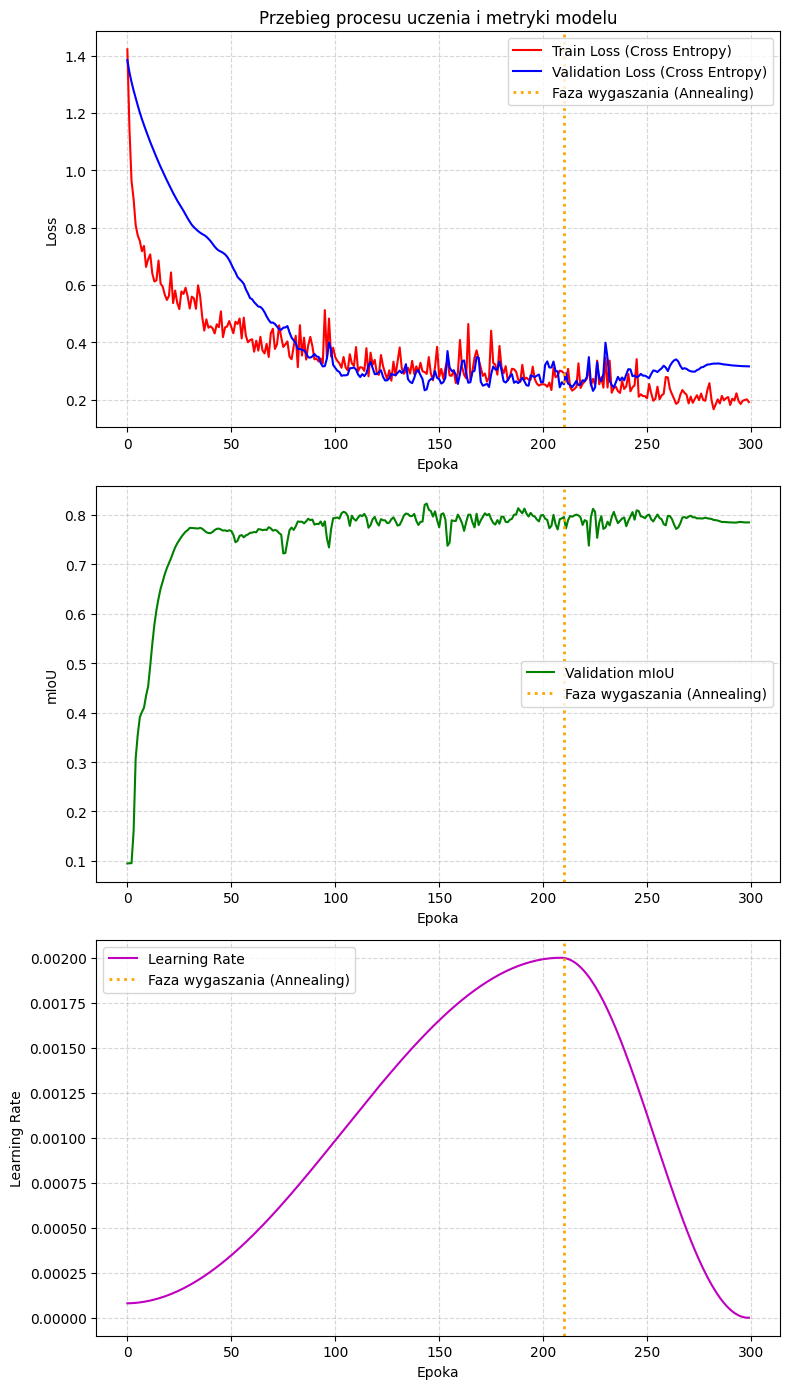

--------------------------------------------------
Liczba kanałów: 3
mIoU: 0.823 

Wynik dot. kanałów: 100.000
Wynik dot. mIoU: 100.000
Estymowana liczba punktów za zadanie: 100


In [27]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI ##########################

if not FINAL_EVALUATION_MODE:
    miou, channels_count = evaluate(train_your_model, YourPreprocessing, VALID_DATA_PATH)
    print("-"*50)
    compute_score(miou, channels_count)

Wykresy obrazują stabilną zbieżność modelu bazowego przy asymetrycznym profilu schedulera nakierowanym na bardzo długą fazę rozgrzewki (`pct_start` = $0.7$). W efekcie, przez pierwsze 210 epok tempo uczenia łagodnie rośnie do wartości maksymalnej ($0.002$), co zapewnia modelowi optymalne warunki do stabilnej eksploracji przestrzeni wag bez ryzyka przedwczesnego rozbieżności gradientu. 

Gwałtowny wzrost wskaźnika mIoU na walidacji następuje już w początkowej fazie (przekroczenie progu 0.75 około 35. epoki), po czym metryka stabilizuje się na wysokim poziomie. 

Przejście w fazę wygaszania (annealing) po 210. epoce (oznaczone pomarańczową linią) pozwala na precyzyjne dociągnięcie wag. Model osiąga bardzo wysoką zdolność generalizacji, przy jednoczesnym braku objawów znacznego przeuczenia. Krzywe straty treningowej i walidacyjnej zbiegają się asymptotycznie i zachowują minimalny dystans przez większość procesu optymalizacji. Dopiero przez ostatnie 50 epok można dostrzec subtelną dywergencję obu krzywych (strata walidacyjna zaczyna minimalnie fluktuować w górę, podczas gdy strata treningowa stale maleje). Niemniej jednak, dzięki zastosowaniu mechanizmu zapisu najlepszego stanu wag (checkpointing) na podstawie najwyższego wyniku metryki mIoU na zbiorze walidacyjnym, zjawisko to zostało całkowicie zneutralizowane, nie wpływając negatywnie na ostateczną jakość końcowego rozwiązania.

-----------------------------

## 6. Bonus - podejście alternatywne

Podczas gdy rozwiązanie podstawowe opierało się na lekkiej sieci konwolucyjnej i redukcji wymiarowości metodą PCA, niniejsza alternatywa zakłada wykorzystanie znacznie potężniejszej architektury typu **Encoder-Decoder z mechanizmem uwagi (Attention)** oraz inteligentną syntezę pasm spektralnych na podstawie wniosków z eskploracyjnej analizy danych (EDA).

**Kluczowa idea**: Zamiast rzutować wszystkie 12 pasm na nową przestrzeń za pomocą ortogonalnych transformacji liniowych (PCA), wykorzystano strukturę powiązań topologicznych wyznaczonych przez analizę klastrową. Za pomocą dendrogramu zidentyfikowaliśmy trzy wyraźne, rozłączne grupy kanałów fizycznych, charakteryzujące się ekstremalnie wysoką korelacją wewnętrzną (współczynniki Pearsona często przekraczające 0.95). Idea Etapu I polega na redukcji wymiarowości metodą nienadzorowanej aglomeracji cech (*feature agglomeration*) — informacja z każdego klastra jest syntetyzowana do postaci jednego kanału poprzez wyznaczenie średniej arytmetycznej z wchodzących w jego skład pasm. W Etapie II tak przygotowane 3 skompresowane reprezentacje fizyczne przetwarzane są przez zaawansowaną sieć Attention U-Net.

In [28]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

### 6.1 Nienadzorowana aglomeracja cech na podstawie dendrogramu
Jak wykazano w jednej z [podsekcji analizy danych](#dendrogram-sekcja), pasma układają się w wyraźne trzy bloki. Analiza struktury dendrogramu macierzy korelacji pozwoliła na naturalny podział 12 pasm teledetekcyjnych na 3 spójne bloki informacyjne i agregację kanałów wewnątrz nich:
* **Blok 1:** uśrednia sygnatury z kanałów: $B2, B4, B8, B11$.
* **Blok 2:** konsoliduje informacje z pasm: $B1, B3, B6, B9, B12$.
* **Blok 3:** agreguje pozostałe cechy: $B5, B7, B10$.

Proces uśredniania informacji w obrębie tych klastrów pozwala na redukcję wymiarowości przestrzeni cech z 12 do 3 bez udziału etykiet i zmiennych docelowych. Takie podejście gwarantuje, że do modelu głębokiego trafiają sygnały o zminimalizowanej multikolinearności, lecz wciąż oparte na realnych, fizycznych uśrednieniach widmowych, co ułatwia późniejszą interpretację map uwagi (*attention maps*) w bottlenecku sieci.

In [29]:
################################### ETAP I: Redukcja danych ####################################
##### Preprocessing danych z wykorzystaniem agregacji klastrów (dendrogram) i normalizacji #####
class YourPreprocessing():
    """
    Klasa przeprowadzająca nienadzorowaną redukcję wymiarowości poprzez 
    uśrednianie skorelowanych pasm wewnątrz 3 klastrów wyznaczonych automatycznie.
    """
    def __init__(self):
        self.mean: torch.Tensor = None
        self.std: torch.Tensor  = None
        self.cluster_mappings: dict[int, list[int]] = {0: [], 1: [], 2: []}
        
    def fit(self, dataset: BaseDataset) -> "YourPreprocessing":
        """Oblicza średnią, odchylenie standardowe oraz automatycznie przydziela pasma do klastrów."""
        dataloader = DataLoader(dataset, batch_size=4, shuffle=False)
        n_channels = next(iter(dataloader))[0].shape[1]
        channel_sum = torch.zeros(n_channels)
        channel_squared_sum = torch.zeros(n_channels)
        num_pixels = 0
        all_features = []
        
        # Zbieranie statystyk i cech dla wszystkich kanałów w celu obliczenia średniej, odchylenia standardowego i macierzy korelacji
        for x, _ in dataloader:
            batch_samples = x.size(0)
            num_pixels += batch_samples * x.size(2) * x.size(3)
            channel_sum += x.sum(dim=[0, 2, 3])
            channel_squared_sum += (x ** 2).sum(dim=[0, 2, 3])
            flat_x = x.permute(0, 2, 3, 1).reshape(-1, n_channels)
            all_features.append(flat_x[::4].cpu())
            
        self.mean = channel_sum / num_pixels
        self.std = torch.sqrt(channel_squared_sum / num_pixels - self.mean ** 2) + 1e-6
        X_sample = torch.cat(all_features, dim=0).numpy()
        corr_matrix = np.corrcoef(X_sample, rowvar=False)

        # Zamiana korelacji na odległość (1 - |korelacja|) do klasteryzacji hierarchicznej
        distance_matrix = 1 - np.abs(corr_matrix)
        condensed_distance = squareform(distance_matrix, checks=False)
        
        # Budowa dendrogramu
        Z = linkage(condensed_distance, method='average')
        # Wyznaczenie granic dla 3 klastrów na podstawie dendrogramu
        labels = fcluster(Z, t=3, criterion='maxclust')
        
        # Mapowanie kanałów do klastrów
        for ch_idx, cluster_label in enumerate(labels):
            self.cluster_mappings[cluster_label - 1].append(ch_idx)
            
        return self

    def transform(self, image_tensor: torch.Tensor) -> torch.Tensor:
        """Normalizuje oryginalne pasma, a następnie agreguje je do 3 wyznaczonych klastrów."""
        # Normalizacja z wykorzystaniem obliczonych średnich i odchyleń standardowych
        normalized = (image_tensor - self.mean[:, None, None]) / self.std[:, None, None]
        
        # Agregacja pasm w ramach klastrów poprzez uśrednianie
        ch1 = normalized[self.cluster_mappings[0], :, :].mean(dim=0, keepdim=True)
        ch2 = normalized[self.cluster_mappings[1], :, :].mean(dim=0, keepdim=True)
        ch3 = normalized[self.cluster_mappings[2], :, :].mean(dim=0, keepdim=True)
        
        # Konkatenacja zredukowanych kanałów do formatu wyjściowego
        reduced_tensor = torch.cat([ch1, ch2, ch3], dim=0)
        return reduced_tensor

### 6.2 Architektura sieci Attention Encoder-Decoder
Zaimplementowany model to zaawansowana sieć typu enkoder-dekoder, składająca się łącznie z 15 warstw (wliczając bloki kodujące, dekodujące, atencję oraz warstwę klasyfikacji).
* **Enkoder** - składa się z 4 bloków EncodingBlock, z których każdy zawiera dwie warstwy konwolucyjne (jądro 3x3) z mechanizmem Batch Normalization i aktywacją ReLU. Zadaniem enkodera jest stopniowe zwiększanie liczby filtrów (od 64 do 512) przy jednoczesnym zmniejszaniu rozdzielczości przestrzennej za pomocą Max Pooling (w pierwszych 3 blokach). Pozwala to na ekstrakcję cech o wysokim poziomie abstrakcji – od prostych krawędzi po złożone struktury urbanistyczne i hydrologiczne.

* **Mechanizm [Attention](https://arxiv.org/abs/1706.03762)** - w najgłębszym punkcie sieci zastosowano moduł Multi-Head Attention (8 głowic). W przeciwieństwie do standardowych konwolucji, mechanizm uwagi pozwala modelowi na analizę relacji dalekosiężnych (long-range dependencies). Dzięki temu sieć może "zrozumieć" kontekst całego zdjęcia satelitarnego, co ułatwia m.in. spójną segmentację dużych zbiorników wodnych czy rozległych obszarów leśnych.

* **Dekoder** - składa się z 3 bloków DecodingBlock, których zadaniem jest przywrócenie mapie cech oryginalnej rozdzielczości obrazu wejściowego. Wykorzystuje operacje konwolucji transponowanej (Up-convolution). Kluczowym elementem są połączenia pomijające (skip connections), które przekazują precyzyjne informacje przestrzenne bezpośrednio z enkodera do dekodera. Zapobiega to utracie detali podczas odtwarzania rozmiaru obrazu.

In [30]:
################################### ETAP II: Segmentacja ####################################
##### Klasa enkodera dla modelu #####
class EncodingBlock(nn.Module):
    """Blok kodujący (downsampling) ekstrahujący cechy za pomocą podwójnej konwolucji."""
    def __init__(self, in_channels: int, out_channels: int, max_pooling: bool = True):
        super(EncodingBlock, self).__init__()
        self.max_pooling = max_pooling
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
        if max_pooling:
            self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        else:
            self.pool = None

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        x = self.conv(x)
        skip = x
        if self.max_pooling:
            x = self.pool(x)
        return x, skip

##### Klasa dekodera dla modelu #####
class DecodingBlock(nn.Module):
    """Blok dekodujący (upsampling) łączący cechy z połączeń pomijających."""
    def __init__(self, in_channels: int, skip_channels: int, out_channels: int):
        super(DecodingBlock, self).__init__()
        self.upconv = nn.Sequential(
            nn.ConvTranspose2d(
                in_channels,
                out_channels,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1,
                bias=False,
            ),
            nn.ReLU(inplace=True),
        )
        self.layers = nn.Sequential(
            nn.Conv2d(
                skip_channels + out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, inputs: torch.Tensor, skip_connection_input: torch.Tensor) -> torch.Tensor:
        x = self.upconv(inputs)
        x = torch.cat([x, skip_connection_input], dim=1)
        x = self.layers(x)
        return x

##### Klasa modelu z mechanizmem atencji i skip connections #####
class YourModel(nn.Module):
    """Architektura koder-dekoder z Multihead Attention w najgłębszej warstwie."""
    def __init__(self, input_channels: int = 12, n_channels: int = 64, n_classes: int = 4):
        super().__init__()
        self.enc1 = EncodingBlock(input_channels, n_channels, max_pooling=True)
        self.enc2 = EncodingBlock(n_channels, n_channels * 2, max_pooling=True)
        self.enc3 = EncodingBlock(n_channels * 2, n_channels * 4, max_pooling=True)
        self.enc4 = EncodingBlock(n_channels * 4, n_channels * 8, max_pooling=False)

        self.attn = nn.MultiheadAttention(n_channels * 8, num_heads=8) # mechanizm atencji w najgłębszej warstwie

        self.dec7 = DecodingBlock(n_channels * 8, n_channels * 4, n_channels * 4)
        self.dec8 = DecodingBlock(n_channels * 4, n_channels * 2, n_channels * 2)
        self.dec9 = DecodingBlock(n_channels * 2, n_channels, n_channels)

        self.conv10 = nn.Conv2d(n_channels, n_channels, kernel_size=3, padding=1)
        self.act10 = nn.ReLU(inplace=True)
        self.conv11 = nn.Conv2d(n_channels, n_classes, kernel_size=1, padding=0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.pad(x, (1, 1, 1, 1))
        c1, s1 = self.enc1(x)
        c2, s2 = self.enc2(c1)
        c3, s3 = self.enc3(c2)
        c4, s4 = self.enc4(c3)

        c4_flat = c4.reshape(c4.shape[0], c4.shape[1], -1).permute(0, 2, 1)
        c4_attn = (
            self.attn(c4_flat, c4_flat, c4_flat)[0].permute(0, 2, 1).reshape(c4.shape)
        )
        c4 = c4 + c4_attn

        u7 = self.dec7(c4, s3)
        u8 = self.dec8(u7, s2)
        u9 = self.dec9(u8, s1)

        c10 = self.conv10(u9)
        c10 = self.act10(c10)
        c11 = self.conv11(c10)
        c11 = c11[:, :, 1:-1, 1:-1]
        return c11

### 6.3 Funkcja straty - Dice Loss

W zadaniach segmentacji obrazów satelitarnych często występuje problem niezbalansowania klas (np. dominacja lądu nad rzadziej występującą zabudową przemysłową). W walidacji danych ten brak balansu klas był również zauważalny. Aby go wyeliminować, zamiast funkcji Cross-Entropy można zastosować ***Dice Loss***, która optymalizuje bezpośrednio nakładanie się masek. Funkcja straty opiera się na miarze podobieństwa zbiorów i dana jest wzorem:

$$L_{Dice} = 1 - \frac{2 \cdot |P \cap G| + \epsilon}{|P| + |G| + \epsilon}$$

Gdzie:
* $P$ to zbiór przewidywanych przez model prawdopodobieństw przynależności pikseli do danej klasy (w masce predykcji),
* $G$ to zbiór rzeczywistych, binarnych etykiet pikseli (tzw. *ground truth*),
* $|P \cap G|$ oznacza przecięcie (iloczyn logiczny) obu masek, realizowane w kodzie jako suma iloczynów odpowiadających sobie pikseli,
* $|P|$ oraz $|G|$ to liczności (sumy wartości) poszczególnych zbiorów,
* $\epsilon$ (*smooth*) to parametr wygładzający, który zapobiega dzieleniu przez zero w przypadku braku danej klasy na obrazie.

In [31]:
# Alternatywna funkcja straty
class DiceLoss(nn.Module):
    """Implementacja Dice Loss z obsługą ignorowanych pikseli."""
    def __init__(self, smooth: float = 1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, inputs: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # Konwersja logitów na prawdopodobieństwa
        inputs = F.softmax(inputs, dim=1)
        
        # Obsługa maskowania (ignorowanie etykiety -1)
        mask = (targets != -1).float()
        targets_clamped = targets.clamp(min=0) # zamiana -1 na 0 tylko do one_hot
        
        # Konwersja etykiety na one-hot [B, H, W] -> [B, H, W, C] -> [B, C, H, W]
        targets_one_hot = F.one_hot(targets_clamped, num_classes=inputs.shape[1])
        targets_one_hot = targets_one_hot.permute(0, 3, 1, 2).float()
        
        # Nałożenie maski na wejście i etykiety
        mask = mask.unsqueeze(1) # [B, 1, H, W]
        inputs = inputs * mask
        targets_one_hot = targets_one_hot * mask
        
        # Obliczanie Intersection i Union
        dims = (0, 2, 3)
        intersection = (inputs * targets_one_hot).sum(dims)
        union = inputs.sum(dims) + targets_one_hot.sum(dims)
        
        # Dice Score i Loss
        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()

Proces uczenia przebiega tak samo, jak w przypadku rozwiązania wzorcowego. Zmieniono wartości poniższych parametrów:
- Proces uczenia wydłużono z 300 epok do **600**, z powodu większej liczby parametrów przez bardziej skomplikowaną architekturę modelu.
- Fazę rozgrzewki (warm-up) w schedulerze zmniejszono z $70\%$ ($210$ epok z $400$) do **$30\%$** całkowitego treningu (**$180$** epok z $600$).
- Batch size zmniejszono z $16$ do $8$.

Takie wartości hiperparametrów przyniosły najlepsze rezultaty na zbiorze walidacyjnym.

In [32]:
##### Pętla treningowa #####
torch.manual_seed(42)
def train_your_model() -> YourModel:
    """Główna procedura treningowa z rozbudowaną augmentacją i wyborem najlepszego stanu wag."""
    epochs = 600
    lr = 0.002
    batch_size = 8
    n_channels = 64
    input_channels = 3
    
    model = YourModel(input_channels=input_channels, n_channels=n_channels, n_classes=4)
    model = model.to(DEVICE)

    raw_train_ds = BaseDataset(data_path=TRAIN_DATA_PATH)
    raw_valid_ds = BaseDataset(data_path=VALID_DATA_PATH)
    
    preprocessing = YourPreprocessing()
    preprocessing.fit(raw_train_ds)
    
    train_ds = transform_dataset(preprocessing=preprocessing, dataset=raw_train_ds)
    valid_ds = transform_dataset(preprocessing=preprocessing, dataset=raw_valid_ds)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    pct_start = 0.3 # Część epok z rosnącym LR, reszta z wygaszaniem
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, 
        max_lr=lr, 
        steps_per_epoch=len(train_loader), 
        epochs=epochs,
        pct_start=pct_start
    )
    criterion = DiceLoss(smooth=1.0)

    model.train()
    best_mious = 0
    best_model = None
    train_losses = []
    val_losses = []
    val_mious = []
    lrs = []

    for _ in tqdm(range(epochs), desc="Trening"):
        epoch_loss = 0.0
        for x, y in train_loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            ## Augmentacje online ##
            # Obroty
            if torch.rand(1) < 0.5:
                x = torch.flip(x, dims=[3])
                y = torch.flip(y, dims=[2])

            if torch.rand(1) < 0.5:
                x = torch.flip(x, dims=[2])
                y = torch.flip(y, dims=[1])
            # Rotacje
            k = torch.randint(0, 4, (1,)).item()
            if k > 0:
                x = torch.rot90(x, k, dims=[2, 3])
                y = torch.rot90(y, k, dims=[1, 2])

            y_pred = model(x)
            loss = criterion(y_pred, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            scheduler.step()
        
        train_losses.append(epoch_loss / len(train_loader))
        lrs.append(optimizer.param_groups[0]['lr'])
    
        # Walidacja i wybór najlepszego modelu (Checkpointing)
        with torch.no_grad():
            valid_loss = 0
            mious = []
            for x, y in valid_loader:
                x = x.to(DEVICE)
                y = y.to(DEVICE)
                
                y_pred = model(x)
                loss = criterion(y_pred, y)

                valid_loss += loss.item()

                y_pred = torch.argmax(y_pred, dim=1)
                miou = calculate_miou(y, y_pred)
                mious.extend(miou)
            
            epoch_miou = sum(mious) / len(mious)
            val_mious.append(epoch_miou)
            val_losses.append(valid_loss / len(valid_loader))
            
            if sum(mious) / len(mious) > best_mious:
                best_mious = sum(mious) / len(mious)
                best_model = model.state_dict()

    ## Wizualizacja procesu uczenia ##
    phase_change_epoch = int(epochs * pct_start)
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 14))
    
    # Wykres 1: Funkcja kosztu
    ax1.plot(train_losses, 'r-', label='Train Loss (Dice)')
    ax1.plot(val_losses, 'b-', label='Validation Loss (Dice)')
    ax1.axvline(x=phase_change_epoch, color='orange', linestyle=':', linewidth=2, label='Faza wygaszania (Annealing)')
    ax1.set_xlabel('Epoka')
    ax1.set_ylabel('Loss')
    ax1.set_title('Przebieg procesu uczenia i metryki (podejście alternatywne)')
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle='--', alpha=0.5)
    
    # Wykres 2: mIoU na zbiorze walidacyjnym
    ax2.plot(val_mious, 'g-', label='Validation mIoU')
    ax2.axvline(x=phase_change_epoch, color='orange', linestyle=':', linewidth=2, label='Faza wygaszania (Annealing)')
    ax2.set_xlabel('Epoka')
    ax2.set_ylabel('mIoU')
    ax2.legend(loc='right')
    ax2.grid(True, linestyle='--', alpha=0.5)
    
    # Wykres 3: Learning Rate i oznaczenie fazy wygaszania
    ax3.plot(lrs, 'm-', label='Learning Rate')
    ax3.axvline(x=phase_change_epoch, color='orange', linestyle=':', linewidth=2, label='Faza wygaszania (Annealing)')
    ax3.set_xlabel('Epoka')
    ax3.set_ylabel('Learning Rate')
    ax3.legend(loc='upper right')
    ax3.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    model.load_state_dict(best_model)
    return model

Trening: 100%|██████████| 600/600 [01:46<00:00,  5.65it/s]


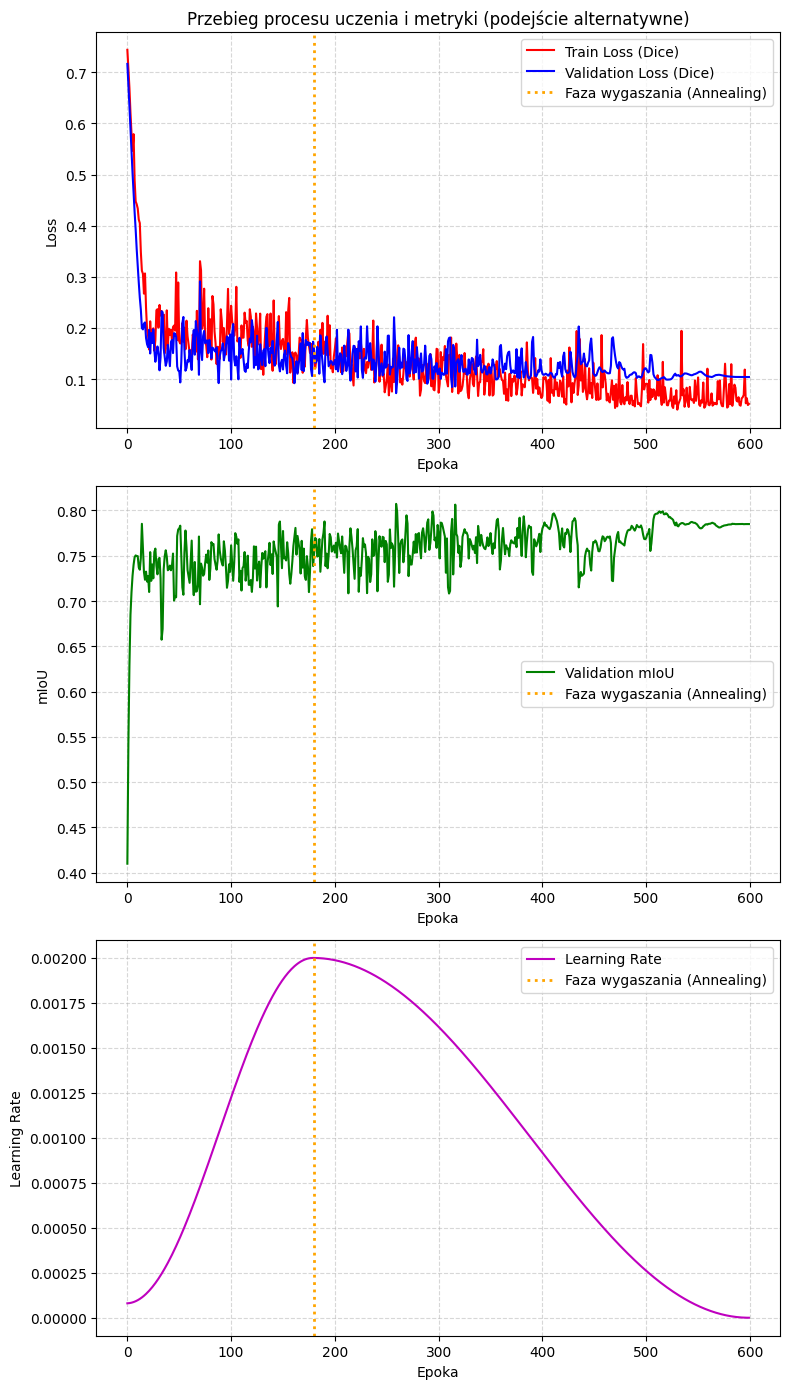

--------------------------------------------------
Liczba kanałów: 3
mIoU: 0.796 

Wynik dot. kanałów: 100.000
Wynik dot. mIoU: 98.213
Estymowana liczba punktów za zadanie: 99


99

In [33]:
miou, channels_count = evaluate(train_your_model, YourPreprocessing, VALID_DATA_PATH)
print("-"*50)
compute_score(miou, channels_count)

Przebieg optymalizacji modelu alternatywnego odzwierciedla asymetryczny profil schedulera ($pct\_start = 0.3$), gdzie faza wygaszania rozpoczyna się po 180 epokach. Zastosowanie funkcji Dice Loss skutkuje **znacznie gwałtowniejszym spadkiem straty** w pierwszych 20 epokach w porównaniu do klasycznego Cross-Entropy zastosowanego w rozwiązaniu wzorcowym. Większa złożoność obliczeniowa architektury oraz drastyczna redukcja wymiarowości cech wejściowych (aglomeracja do 3 kanałów) objawia się widocznymi fluktuacjami wskaźnika mIoU. Dopiero w końcowej fazie głębokiego wygaszania (po 500 epokach) następuje ostateczna stabilizacja wag, owocując wynikiem $mIoU = 0.796$.

Nieznacznie niższa skuteczność w stosunku do modelu bazowego sugeruje, że dla analizowanego, ograniczonego wolumenu danych prostsza architektura konwolucyjna charakteryzuje się lepszą stabilnością numeryczną. Rozwiązanie alternatywne potrzebowało również znacznie większej liczby epok, aby osiągnąć zadowalającą zbieżność. Niemniej jednak, w scenariuszu dysponowania znacznie większym zbiorem danych treningowych, to podejście alternatywne posiada znacznie wyższy sufit wydajnościowy. Wynika to z jego dużej pojemności architektonicznej, większej liczby parametrów oraz zdolności mechanizmu atencji do wychwytywania globalnych zależności kontekstowych bez utraty rozdzielczości przestrzennej, co przy odpowiedniej skali danych pozwoliłoby na osiągnięcie przewagi nad modelem bazowym.